In [2]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_rg3
from common.train_test_split import split_data
from common.model_composition import model_composition

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_rg3 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3.csv")

DEVICE : cpu
RAW DATA
Shape : (1182, 26)

Columns:
['Unnamed: 0', 'PassOrFail', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

Target:
PassOrFail
0    1157
1      25
Name: count, dtype: int64

Detected time column: None

Side encoding:
0 -> ALL

Prediction horizon: 0

BASE SENSOR FEATURES
개수: 24
Injection_Time
Filling_Time
Plasticizing_Time
Cycle_Time
Clamp_Close_Time
Cushion_Position
Plasticizing_Position
Clamp_Open_Position
Max_Injection_Speed
Max_Screw_RPM
Average_Screw_RPM
Max_Injection_Pressure
Max_Switch_Ov

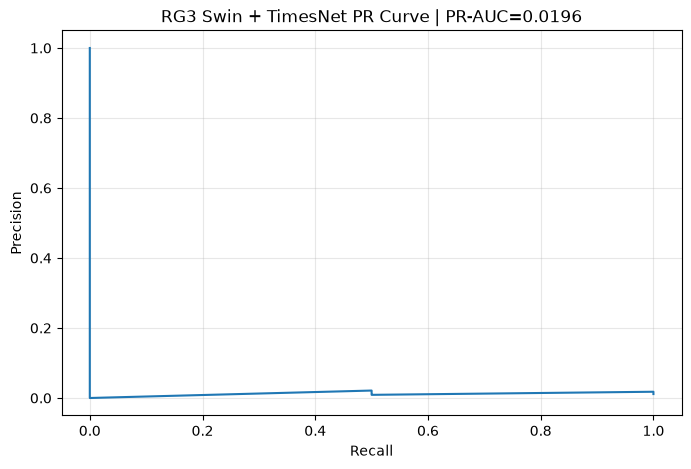

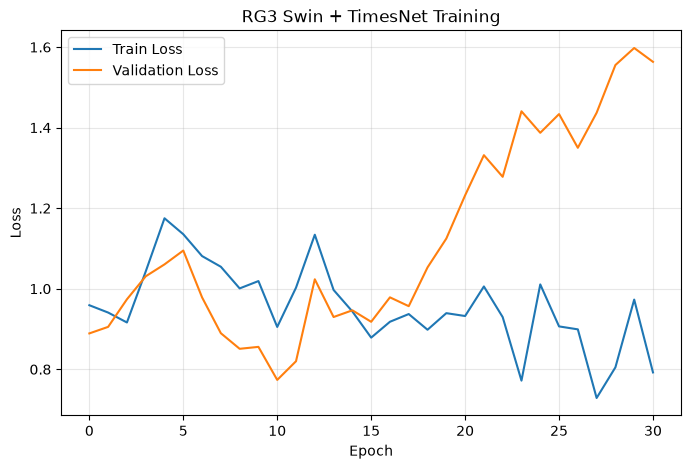


Saved: rg3_swin_timesnet_predictions.csv
Saved: rg3_swin_timesnet_model.pt
Saved: rg3_swin_timesnet_preprocessors.pkl


In [4]:
# ============================================================
# RG3 - Tiny Swin Transformer + TimesNet Fusion
#
# Pipeline
# ------------------------------------------------------------
# 1. Load RG3
# 2. Sort chronologically
# 3. Target / Side preprocessing
# 4. Sensor feature selection
# 5. Lag / Diff / Rolling feature engineering
# 6. Train-only imputation / variance filtering / scaling
# 7. Train-only feature selection
# 8. Side-specific sequence window generation
# 9. TimesNet branch
# 10. Tiny Swin branch
# 11. Feature fusion
# 12. Imbalance-aware training
# 13. Threshold optimization
# 14. PR-AUC / ROC-AUC / Precision / Recall / F1 / F2
# 15. Save model / prediction
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import os
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.models.swin_transformer import SwinTransformer


warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

SEED = 42

CSV_PATH = r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3.csv"

TARGET = "PassOrFail"
SIDE_COL = "Side"

# 같은 Side 기준 과거 몇 개 생산 시점을 볼 것인지
SEQ_LEN = 16

# 현재 공정으로 현재 불량 판정
# 0 = 현재 cycle 불량 분류
#
# 1 = 다음 cycle 불량 예측
# 2 = 2 cycle 뒤 불량 예측
PREDICT_HORIZON = 0

# chronological split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# Test = 나머지 0.15

# TimesNet에 넣을 최대 feature 개수
MAX_TIMESNET_FEATURES = 64

# Swin sensor map 크기
SWIN_IMAGE_SIZE = 64

BATCH_SIZE = 32
EPOCHS = 80

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 10

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 2. RANDOM SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("DEVICE :", DEVICE)


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("RAW DATA")
print("=" * 70)

print("Shape :", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget:")
print(df[TARGET].value_counts(dropna=False))

if SIDE_COL in df.columns:
    print("\nSide:")
    print(df[SIDE_COL].value_counts(dropna=False))


# ============================================================
# 4. TARGET NORMALIZATION
# ============================================================

def normalize_target(series):

    # 숫자로 변환 가능한 경우
    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    unique_numeric = set(
        numeric.dropna().unique()
    )

    if unique_numeric.issubset({0, 1}):

        return numeric.astype("Int64")

    # 문자열 Target일 경우
    mapping = {
        "pass": 0,
        "normal": 0,
        "ok": 0,
        "good": 0,

        "fail": 1,
        "defect": 1,
        "ng": 1,
        "bad": 1,
    }

    converted = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

    if converted.isna().any():

        raise ValueError(
            "Target 값을 0/1로 변환할 수 없습니다.\n"
            f"Target unique = {series.unique()}"
        )

    return converted.astype(int)


df[TARGET] = normalize_target(df[TARGET])


# ============================================================
# 5. TIME SORT
# ============================================================

TIME_CANDIDATES = [
    "timestamp",
    "Timestamp",
    "datetime",
    "Datetime",
    "DateTime",
    "PART_FACT_PLAN_DATE",
    "date",
    "Date",
]


def chronological_sort(data):

    data = data.copy()

    detected_time = None

    for col in TIME_CANDIDATES:

        if col not in data.columns:
            continue

        parsed = pd.to_datetime(
            data[col],
            errors="coerce"
        )

        if parsed.notna().sum() > 0:

            data["__time__"] = parsed

            detected_time = col

            break

    sort_cols = []

    if detected_time is not None:
        sort_cols.append("__time__")

    # 동일 날짜 내부 생산 순서 보조
    if "PART_FACT_SERIAL" in data.columns:
        sort_cols.append("PART_FACT_SERIAL")

    if sort_cols:

        data = (
            data
            .sort_values(sort_cols)
            .reset_index(drop=True)
        )

    else:

        print(
            "WARNING: 시간 컬럼을 찾지 못했습니다. "
            "현재 CSV 행 순서를 생산 순서로 사용합니다."
        )

        data = data.reset_index(drop=True)

    return data, detected_time


df, detected_time = chronological_sort(df)

print("\nDetected time column:", detected_time)


# ============================================================
# 6. SIDE ENCODING
# ============================================================

if SIDE_COL in df.columns:

    side_string = (
        df[SIDE_COL]
        .astype(str)
        .str.upper()
        .str.strip()
    )

else:

    df[SIDE_COL] = "ALL"
    side_string = df[SIDE_COL]


# factorize
side_codes, side_names = pd.factorize(side_string)

df["__side_code__"] = side_codes


print("\nSide encoding:")

for i, side in enumerate(side_names):
    print(i, "->", side)


NUM_SIDES = len(side_names)


# ============================================================
# 7. HORIZON TARGET
# ============================================================

# 같은 RH/LH 생산라인 안에서 미래 Target을 이동시킴

if PREDICT_HORIZON == 0:

    df["__label__"] = df[TARGET].astype(float)

else:

    df["__label__"] = (
        df
        .groupby("__side_code__", sort=False)[TARGET]
        .shift(-PREDICT_HORIZON)
        .astype(float)
    )


print("\nPrediction horizon:", PREDICT_HORIZON)


# ============================================================
# 8. ID / META COLUMN 제거
# ============================================================

ID_COLUMNS = {
    TARGET,
    SIDE_COL,

    "__time__",
    "__label__",
    "__side_code__",

    "PART_FACT_SERIAL",
    "PART_FACT_PLAN_DATE",

    "Unnamed: 0",
    "index",
}


# object인데 사실 숫자인 column 처리
for col in df.columns:

    if col in ID_COLUMNS:
        continue

    if df[col].dtype == "object":

        converted = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        # 95% 이상 숫자 변환 가능하면 numeric으로 사용
        if converted.notna().mean() >= 0.95:

            df[col] = converted


BASE_FEATURES = [
    col
    for col in df.columns
    if (
        col not in ID_COLUMNS
        and pd.api.types.is_numeric_dtype(df[col])
    )
]


print("\n" + "=" * 70)
print("BASE SENSOR FEATURES")
print("=" * 70)

print("개수:", len(BASE_FEATURES))

for col in BASE_FEATURES:
    print(col)


# ============================================================
# 9. FEATURE ENGINEERING
# ============================================================
#
# 원본
# +
# lag1
# lag2
# diff1
# rolling 3 mean
# rolling 5 mean
# rolling 5 std
#
# IMPORTANT
# rolling은 같은 Side끼리 계산
# ============================================================


def make_engineered_features(
    data,
    base_features
):

    result = data.copy()

    new_features = {}

    group_key = result["__side_code__"]

    for col in base_features:

        grouped = result.groupby(
            "__side_code__",
            sort=False
        )[col]

        # ----------------------------------------------------
        # Lag
        # ----------------------------------------------------

        new_features[
            f"{col}_lag1"
        ] = grouped.shift(1)

        new_features[
            f"{col}_lag2"
        ] = grouped.shift(2)

        # ----------------------------------------------------
        # Difference
        # 현재 - 직전
        # ----------------------------------------------------

        new_features[
            f"{col}_diff1"
        ] = grouped.diff(1)

        # ----------------------------------------------------
        # Rolling
        #
        # shift(1)을 먼저 사용하여
        # 과거 정보만 rolling에 포함
        # ----------------------------------------------------

        new_features[
            f"{col}_roll3_mean"
        ] = (
            result
            .groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    window=3,
                    min_periods=1
                )
                .mean()
            )
        )

        new_features[
            f"{col}_roll5_mean"
        ] = (
            result
            .groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    window=5,
                    min_periods=1
                )
                .mean()
            )
        )

        new_features[
            f"{col}_roll5_std"
        ] = (
            result
            .groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    window=5,
                    min_periods=2
                )
                .std()
            )
        )

    engineered_df = pd.DataFrame(
        new_features,
        index=result.index
    )

    result = pd.concat(
        [
            result,
            engineered_df
        ],
        axis=1
    )

    return result


df = make_engineered_features(
    df,
    BASE_FEATURES
)


ENGINEERED_FEATURES = [
    col
    for col in df.columns
    if (
        col not in ID_COLUMNS
        and col not in {
            "__label__",
            "__side_code__",
        }
        and pd.api.types.is_numeric_dtype(df[col])
    )
]


print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

print("Original features :", len(BASE_FEATURES))
print("Total features    :", len(ENGINEERED_FEATURES))


# ============================================================
# 10. CHRONOLOGICAL SPLIT 기준점
# ============================================================

N = len(df)

TRAIN_END = int(
    N * TRAIN_RATIO
)

VAL_END = int(
    N * (
        TRAIN_RATIO
        + VAL_RATIO
    )
)


print("\n" + "=" * 70)
print("TIME SPLIT")
print("=" * 70)

print("Train rows :", 0, "~", TRAIN_END - 1)
print("Val rows   :", TRAIN_END, "~", VAL_END - 1)
print("Test rows  :", VAL_END, "~", N - 1)


row_indices = np.arange(N)

train_row_mask = (
    row_indices < TRAIN_END
)

valid_label_mask = (
    df["__label__"]
    .notna()
    .values
)

feature_fit_mask = (
    train_row_mask
    & valid_label_mask
)


# ============================================================
# 11. PREPROCESSOR
# ============================================================
#
# 반드시 TRAIN으로만
#
# 1. Median Imputation
# 2. Constant / zero variance 제거
# 3. StandardScaler
# 4. ANOVA feature selection
#
# Swin:
#     원본 sensor만 사용
#
# TimesNet:
#     원본 + lag + rolling + diff 사용
# ============================================================


def fit_feature_pipeline(
    data,
    feature_columns,
    fit_mask,
    labels,
    max_features=None,
):

    X_df = (
        data[feature_columns]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

    # -------------------------------------------
    # Imputation
    # -------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    imputer.fit(
        X_df.loc[fit_mask]
    )

    X = imputer.transform(
        X_df
    )

    # -------------------------------------------
    # Variance threshold
    # -------------------------------------------

    variance = VarianceThreshold(
        threshold=1e-10
    )

    variance.fit(
        X[fit_mask]
    )

    X = variance.transform(
        X
    )

    variance_names = np.array(
        feature_columns
    )[variance.get_support()]

    # -------------------------------------------
    # Scaling
    # -------------------------------------------

    scaler = StandardScaler()

    scaler.fit(
        X[fit_mask]
    )

    X = scaler.transform(
        X
    )

    # -------------------------------------------
    # Feature selection
    # -------------------------------------------

    selector = None

    selected_names = variance_names

    if max_features is not None:

        k = min(
            max_features,
            X.shape[1]
        )

        if k < X.shape[1]:

            selector = SelectKBest(
                score_func=f_classif,
                k=k
            )

            selector.fit(
                X[fit_mask],
                labels[fit_mask]
            )

            X = selector.transform(
                X
            )

            selected_names = variance_names[
                selector.get_support()
            ]

    pipeline = {

        "feature_columns":
            feature_columns,

        "imputer":
            imputer,

        "variance":
            variance,

        "scaler":
            scaler,

        "selector":
            selector,

        "selected_names":
            selected_names,
    }

    return (
        X.astype(np.float32),
        pipeline,
        selected_names,
    )


labels_all = (
    df["__label__"]
    .fillna(0)
    .values
    .astype(int)
)


# ============================================================
# 12. SWIN SENSOR DATA
# ============================================================

X_swin_all, swin_preprocessor, swin_names = (
    fit_feature_pipeline(
        data=df,
        feature_columns=BASE_FEATURES,
        fit_mask=feature_fit_mask,
        labels=labels_all,
        max_features=None,
    )
)


# ============================================================
# 13. TIMESNET ENGINEERED DATA
# ============================================================

X_times_all, times_preprocessor, times_names = (
    fit_feature_pipeline(
        data=df,
        feature_columns=ENGINEERED_FEATURES,
        fit_mask=feature_fit_mask,
        labels=labels_all,
        max_features=MAX_TIMESNET_FEATURES,
    )
)


print("\n" + "=" * 70)
print("PREPROCESSING RESULT")
print("=" * 70)

print(
    "Swin sensor features :",
    X_swin_all.shape[1]
)

print(
    "TimesNet features    :",
    X_times_all.shape[1]
)


print("\nTimesNet selected features:")

for col in times_names:
    print(" -", col)


# ============================================================
# 14. SEQUENCE WINDOW 생성
# ============================================================
#
# 매우 중요
#
# LH sequence
# RH sequence
#
# 따로 생성
#
# LH와 RH가 한 window에서 섞이지 않음
# ============================================================


def build_sequences(
    X_times,
    X_swin,
    labels,
    side_codes,
    seq_len,
):

    times_sequences = []
    swin_sequences = []

    ys = []
    sides = []
    end_indices = []

    unique_sides = np.unique(
        side_codes
    )

    for side in unique_sides:

        side_positions = np.where(
            side_codes == side
        )[0]

        for j in range(
            seq_len - 1,
            len(side_positions)
        ):

            end_idx = (
                side_positions[j]
            )

            if np.isnan(
                df.loc[
                    end_idx,
                    "__label__"
                ]
            ):
                continue

            sequence_indices = (
                side_positions[
                    j - seq_len + 1
                    :
                    j + 1
                ]
            )

            times_sequences.append(
                X_times[
                    sequence_indices
                ]
            )

            swin_sequences.append(
                X_swin[
                    sequence_indices
                ]
            )

            ys.append(
                int(labels[end_idx])
            )

            sides.append(
                int(side)
            )

            end_indices.append(
                int(end_idx)
            )

    return (
        np.asarray(
            times_sequences,
            dtype=np.float32
        ),
        np.asarray(
            swin_sequences,
            dtype=np.float32
        ),
        np.asarray(
            ys,
            dtype=np.int64
        ),
        np.asarray(
            sides,
            dtype=np.int64
        ),
        np.asarray(
            end_indices,
            dtype=np.int64
        ),
    )


(
    X_times_seq,
    X_swin_seq,
    y_seq,
    side_seq,
    end_seq,
) = build_sequences(
    X_times=X_times_all,
    X_swin=X_swin_all,
    labels=df["__label__"].values,
    side_codes=df["__side_code__"].values,
    seq_len=SEQ_LEN,
)


print("\n" + "=" * 70)
print("SEQUENCE DATA")
print("=" * 70)

print(
    "TimesNet:",
    X_times_seq.shape
)

print(
    "Swin:",
    X_swin_seq.shape
)

print(
    "Target:",
    y_seq.shape
)


# ============================================================
# 15. WINDOW 기준 TRAIN / VAL / TEST
# ============================================================

train_mask = (
    end_seq < TRAIN_END
)

val_mask = (
    (end_seq >= TRAIN_END)
    &
    (end_seq < VAL_END)
)

test_mask = (
    end_seq >= VAL_END
)


def split_array(
    array,
    mask
):
    return array[mask]


X_times_train = split_array(
    X_times_seq,
    train_mask
)

X_times_val = split_array(
    X_times_seq,
    val_mask
)

X_times_test = split_array(
    X_times_seq,
    test_mask
)


X_swin_train = split_array(
    X_swin_seq,
    train_mask
)

X_swin_val = split_array(
    X_swin_seq,
    val_mask
)

X_swin_test = split_array(
    X_swin_seq,
    test_mask
)


y_train = split_array(
    y_seq,
    train_mask
)

y_val = split_array(
    y_seq,
    val_mask
)

y_test = split_array(
    y_seq,
    test_mask
)


side_train = split_array(
    side_seq,
    train_mask
)

side_val = split_array(
    side_seq,
    val_mask
)

side_test = split_array(
    side_seq,
    test_mask
)


end_train = split_array(
    end_seq,
    train_mask
)

end_val = split_array(
    end_seq,
    val_mask
)

end_test = split_array(
    end_seq,
    test_mask
)


def show_split(
    name,
    y
):

    normal = int(
        (y == 0).sum()
    )

    defect = int(
        (y == 1).sum()
    )

    rate = (
        defect / len(y)
        if len(y)
        else 0
    )

    print(
        f"{name:5s} | "
        f"N={len(y):4d} | "
        f"Normal={normal:4d} | "
        f"Defect={defect:3d} | "
        f"Defect rate={rate:.4f}"
    )


print("\n" + "=" * 70)
print("WINDOW SPLIT")
print("=" * 70)

show_split(
    "Train",
    y_train
)

show_split(
    "Val",
    y_val
)

show_split(
    "Test",
    y_test
)


# ============================================================
# 16. PYTORCH DATASET
# ============================================================

class RG3Dataset(Dataset):

    def __init__(
        self,
        X_times,
        X_swin,
        y,
        side,
    ):

        self.X_times = torch.tensor(
            X_times,
            dtype=torch.float32
        )

        self.X_swin = torch.tensor(
            X_swin,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

        self.side = torch.tensor(
            side,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.y)

    def __getitem__(
        self,
        idx
    ):

        return (
            self.X_times[idx],
            self.X_swin[idx],
            self.side[idx],
            self.y[idx],
        )


train_dataset = RG3Dataset(
    X_times_train,
    X_swin_train,
    y_train,
    side_train,
)

val_dataset = RG3Dataset(
    X_times_val,
    X_swin_val,
    y_val,
    side_val,
)

test_dataset = RG3Dataset(
    X_times_test,
    X_swin_test,
    y_test,
    side_test,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


# ============================================================
# 17. TIMESNET
# ============================================================
#
# FFT -> 주요 주기 탐색
# 1D time series -> 2D temporal map
# Conv2D
# 여러 period result를 weighted fusion
# ============================================================


class InceptionBlock2D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        num_kernels=3,
    ):

        super().__init__()

        self.kernels = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=2 * i + 1,
                    padding=i,
                )
                for i in range(
                    num_kernels
                )
            ]
        )

    def forward(
        self,
        x
    ):

        outputs = [
            conv(x)
            for conv in self.kernels
        ]

        outputs = torch.stack(
            outputs,
            dim=-1
        )

        return outputs.mean(
            dim=-1
        )


# ============================================================
# FFT PERIOD DETECTION
# ============================================================

def FFT_for_Period(
    x,
    k=3
):

    # x
    # [batch, time, channel]

    xf = torch.fft.rfft(
        x,
        dim=1
    )

    # 전체 batch / feature 평균 amplitude
    frequency_strength = (
        xf
        .abs()
        .mean(0)
        .mean(-1)
    )

    # DC component 제외
    frequency_strength[0] = (
        -torch.inf
    )

    max_k = max(
        1,
        frequency_strength.numel() - 1
    )

    k = min(
        k,
        max_k
    )

    top_indices = torch.topk(
        frequency_strength,
        k
    ).indices

    T = x.size(1)

    periods = []

    for idx in top_indices:

        freq_idx = int(
            idx.item()
        )

        period = max(
            1,
            T // freq_idx
        )

        periods.append(
            period
        )

    # 각 sample별 주기 strength
    weights = (
        xf
        .abs()
        .mean(-1)[
            :,
            top_indices
        ]
    )

    return periods, weights


# ============================================================
# TIMES BLOCK
# ============================================================

class TimesBlock(nn.Module):

    def __init__(
        self,
        d_model=32,
        top_k=3,
        num_kernels=3,
    ):

        super().__init__()

        self.top_k = top_k

        self.conv = nn.Sequential(

            InceptionBlock2D(
                d_model,
                d_model * 2,
                num_kernels
            ),

            nn.GELU(),

            InceptionBlock2D(
                d_model * 2,
                d_model,
                num_kernels
            ),
        )

    def forward(
        self,
        x
    ):

        B, T, C = x.shape

        periods, period_weights = (
            FFT_for_Period(
                x,
                self.top_k
            )
        )

        outputs = []

        for period in periods:

            # -------------------------------------
            # period에 맞게 padding
            # -------------------------------------

            target_length = (
                (
                    T
                    + period
                    - 1
                )
                // period
            ) * period

            if target_length > T:

                padding = torch.zeros(
                    B,
                    target_length - T,
                    C,
                    device=x.device,
                    dtype=x.dtype,
                )

                x_pad = torch.cat(
                    [
                        x,
                        padding
                    ],
                    dim=1
                )

            else:

                x_pad = x

            # -------------------------------------
            # 1D -> 2D
            #
            # [B,T,C]
            # ->
            # [B,C,n_period,period]
            # -------------------------------------

            y = x_pad.reshape(
                B,
                target_length // period,
                period,
                C,
            )

            y = y.permute(
                0,
                3,
                1,
                2
            ).contiguous()

            # -------------------------------------
            # Inception Conv
            # -------------------------------------

            y = self.conv(
                y
            )

            # -------------------------------------
            # 2D -> 1D
            # -------------------------------------

            y = y.permute(
                0,
                2,
                3,
                1
            ).reshape(
                B,
                target_length,
                C
            )

            y = y[
                :,
                :T,
                :
            ]

            outputs.append(
                y
            )

        # [B,T,C,K]
        outputs = torch.stack(
            outputs,
            dim=-1
        )

        period_weights = F.softmax(
            period_weights,
            dim=1
        )

        period_weights = (
            period_weights
            .unsqueeze(1)
            .unsqueeze(1)
        )

        # weighted fusion
        output = (
            outputs
            * period_weights
        ).sum(
            dim=-1
        )

        # residual
        return output + x


# ============================================================
# TIMESNET ENCODER
# ============================================================

class TimesNetEncoder(nn.Module):

    def __init__(
        self,
        n_features,
        d_model=32,
        e_layers=2,
        top_k=3,
        dropout=0.2,
    ):

        super().__init__()

        self.input_projection = nn.Linear(
            n_features,
            d_model
        )

        self.blocks = nn.ModuleList(
            [
                TimesBlock(
                    d_model=d_model,
                    top_k=top_k,
                )
                for _ in range(
                    e_layers
                )
            ]
        )

        self.norms = nn.ModuleList(
            [
                nn.LayerNorm(
                    d_model
                )
                for _ in range(
                    e_layers
                )
            ]
        )

        self.dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x
    ):

        x = self.input_projection(
            x
        )

        for block, norm in zip(
            self.blocks,
            self.norms
        ):

            x = block(
                x
            )

            x = norm(
                x
            )

            x = self.dropout(
                x
            )

        # temporal global pooling
        x = x.mean(
            dim=1
        )

        return x


# ============================================================
# 18. TINY SWIN TRANSFORMER
# ============================================================
#
# Input
# [B, T, Sensors]
#
# ->
#
# [B, 1, Sensors, Time]
#
# ->
# Resize 64 x 64
#
# ->
# 3 channel
#
# ->
# Swin
# ============================================================


class TinySwinEncoder(nn.Module):

    def __init__(
        self,
        output_dim=96,
        image_size=64,
    ):

        super().__init__()

        self.image_size = (
            image_size
        )

        # torchvision 기본 Swin-T보다
        # 훨씬 작은 구조
        self.swin = SwinTransformer(

            patch_size=[
                4,
                4
            ],

            embed_dim=24,

            depths=[
                1,
                1,
                2
            ],

            num_heads=[
                2,
                4,
                8
            ],

            window_size=[
                4,
                4
            ],

            mlp_ratio=3.0,

            dropout=0.10,

            attention_dropout=0.10,

            stochastic_depth_prob=0.10,

            num_classes=output_dim,
        )

    def forward(
        self,
        x
    ):

        # x:
        # [B,T,F]

        # [B,F,T]
        x = x.transpose(
            1,
            2
        )

        # [B,1,F,T]
        x = x.unsqueeze(
            1
        )

        # sensor × time map
        x = F.interpolate(
            x,
            size=(
                self.image_size,
                self.image_size
            ),
            mode="bilinear",
            align_corners=False,
        )

        # Swin expects 3 channel
        x = x.repeat(
            1,
            3,
            1,
            1
        )

        return self.swin(
            x
        )


# ============================================================
# 19. SWIN + TIMESNET FUSION
# ============================================================

class SwinTimesNetFusion(nn.Module):

    def __init__(
        self,
        times_features,
        num_sides,
    ):

        super().__init__()

        self.timesnet = (
            TimesNetEncoder(
                n_features=times_features,
                d_model=32,
                e_layers=2,
                top_k=3,
                dropout=0.20,
            )
        )

        self.swin = (
            TinySwinEncoder(
                output_dim=96,
                image_size=SWIN_IMAGE_SIZE,
            )
        )

        # LH / RH 정보
        self.side_embedding = (
            nn.Embedding(
                max(
                    num_sides,
                    1
                ),
                4
            )
        )

        # 32 TimesNet
        # +
        # 96 Swin
        # +
        # 4 Side
        fusion_dim = (
            32
            + 96
            + 4
        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(
                fusion_dim
            ),

            nn.Linear(
                fusion_dim,
                64
            ),

            nn.GELU(),

            nn.Dropout(
                0.35
            ),

            nn.Linear(
                64,
                32
            ),

            nn.GELU(),

            nn.Dropout(
                0.25
            ),

            nn.Linear(
                32,
                1
            ),
        )

    def forward(
        self,
        x_times,
        x_swin,
        side
    ):

        times_feature = (
            self.timesnet(
                x_times
            )
        )

        swin_feature = (
            self.swin(
                x_swin
            )
        )

        side_feature = (
            self.side_embedding(
                side
            )
        )

        fused = torch.cat(
            [
                times_feature,
                swin_feature,
                side_feature
            ],
            dim=1
        )

        logits = (
            self.classifier(
                fused
            )
            .squeeze(1)
        )

        return logits


# ============================================================
# 20. MODEL CREATE
# ============================================================

model = SwinTimesNetFusion(

    times_features=
        X_times_train.shape[2],

    num_sides=
        NUM_SIDES,

).to(
    DEVICE
)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 70)
print("MODEL")
print("=" * 70)

print(
    "Total params:",
    f"{total_params:,}"
)

print(
    "Trainable params:",
    f"{trainable_params:,}"
)


# ============================================================
# 21. CLASS IMBALANCE
# ============================================================
#
# RG3 불량 비율이 극단적으로 낮으므로
# BCE pos_weight 사용
#
# 너무 큰 weight는 불안정할 수 있으므로 20 cap
# ============================================================

positive_count = max(
    int(
        (y_train == 1).sum()
    ),
    1
)

negative_count = int(
    (y_train == 0).sum()
)

raw_pos_weight = (
    negative_count
    / positive_count
)

POS_WEIGHT = min(
    raw_pos_weight,
    20.0
)


print("\nRaw pos_weight :", raw_pos_weight)
print("Used pos_weight:", POS_WEIGHT)


criterion = (
    nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [POS_WEIGHT],
            device=DEVICE
        )
    )
)


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=3,
    )
)


# ============================================================
# 22. EVALUATE
# ============================================================

@torch.no_grad()
def predict_loader(
    model,
    loader,
    criterion=None,
):

    model.eval()

    all_y = []
    all_prob = []

    total_loss = 0
    total_count = 0

    for (
        x_times,
        x_swin,
        side,
        y
    ) in loader:

        x_times = x_times.to(
            DEVICE
        )

        x_swin = x_swin.to(
            DEVICE
        )

        side = side.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )

        logits = model(
            x_times,
            x_swin,
            side
        )

        if criterion is not None:

            loss = criterion(
                logits,
                y
            )

            total_loss += (
                loss.item()
                * len(y)
            )

            total_count += (
                len(y)
            )

        prob = torch.sigmoid(
            logits
        )

        all_y.extend(
            y
            .cpu()
            .numpy()
        )

        all_prob.extend(
            prob
            .cpu()
            .numpy()
        )

    avg_loss = (
        total_loss / total_count
        if total_count
        else np.nan
    )

    return (
        avg_loss,
        np.asarray(all_y),
        np.asarray(all_prob),
    )


# ============================================================
# 23. SAFE PR-AUC
# ============================================================

def safe_pr_auc(
    y_true,
    probabilities
):

    if len(
        np.unique(
            y_true
        )
    ) < 2:

        return np.nan

    return average_precision_score(
        y_true,
        probabilities
    )


# ============================================================
# 24. TRAINING
# ============================================================

best_score = -np.inf

best_state = None

patience_counter = 0

history = {

    "train_loss": [],
    "val_loss": [],
    "val_pr_auc": [],
}


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    running_loss = 0
    running_count = 0

    for (
        x_times,
        x_swin,
        side,
        y
    ) in train_loader:

        x_times = x_times.to(
            DEVICE
        )

        x_swin = x_swin.to(
            DEVICE
        )

        side = side.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            x_times,
            x_swin,
            side
        )

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += (
            loss.item()
            * len(y)
        )

        running_count += (
            len(y)
        )

    train_loss = (
        running_loss
        / running_count
    )

    (
        val_loss,
        val_true,
        val_prob
    ) = predict_loader(
        model,
        val_loader,
        criterion
    )

    val_pr_auc = safe_pr_auc(
        val_true,
        val_prob
    )

    # Validation에 불량이 없을 경우
    # loss를 score 대용으로 사용
    if np.isnan(
        val_pr_auc
    ):

        score = (
            -val_loss
        )

    else:

        score = (
            val_pr_auc
        )

    scheduler.step(
        score
    )

    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "val_pr_auc"
    ].append(
        val_pr_auc
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss {train_loss:.5f} | "
        f"Val Loss {val_loss:.5f} | "
        f"Val PR-AUC {val_pr_auc:.5f} | "
        f"LR {current_lr:.2e}"
    )

    # ---------------------------------------------
    # Early stopping
    # ---------------------------------------------

    if score > best_score:

        best_score = score

        best_state = {
            key:
                value
                .detach()
                .cpu()
                .clone()

            for key, value
            in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping."
            )

            break


# ============================================================
# 25. LOAD BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )

model = model.to(
    DEVICE
)


# ============================================================
# 26. VALIDATION THRESHOLD OPTIMIZATION
# ============================================================
#
# defect recall이 중요하므로
# F2 기준 threshold 선택
# ============================================================

(
    _,
    val_true,
    val_prob
) = predict_loader(
    model,
    val_loader
)


def find_best_threshold(
    y_true,
    probabilities,
    beta=2.0
):

    if len(
        np.unique(
            y_true
        )
    ) < 2:

        print(
            "WARNING: Validation에 "
            "두 class가 모두 존재하지 않습니다."
        )

        return 0.5, np.nan

    best_threshold = 0.5
    best_fbeta = -1

    thresholds = np.arange(
        0.01,
        1.00,
        0.01
    )

    for threshold in thresholds:

        pred = (
            probabilities
            >= threshold
        ).astype(int)

        score = fbeta_score(
            y_true,
            pred,
            beta=beta,
            zero_division=0
        )

        if score > best_fbeta:

            best_fbeta = score
            best_threshold = threshold

    return (
        best_threshold,
        best_fbeta
    )


BEST_THRESHOLD, val_f2 = (
    find_best_threshold(
        val_true,
        val_prob,
        beta=2
    )
)


print("\n" + "=" * 70)
print("BEST THRESHOLD")
print("=" * 70)

print(
    "Threshold:",
    BEST_THRESHOLD
)

print(
    "Validation F2:",
    val_f2
)


# ============================================================
# 27. TEST
# ============================================================

(
    test_loss,
    test_true,
    test_prob
) = predict_loader(
    model,
    test_loader,
    criterion
)


test_pred = (
    test_prob
    >= BEST_THRESHOLD
).astype(int)


# ============================================================
# 28. METRICS
# ============================================================

test_pr_auc = safe_pr_auc(
    test_true,
    test_prob
)


if (
    len(
        np.unique(
            test_true
        )
    ) >= 2
):

    test_roc_auc = (
        roc_auc_score(
            test_true,
            test_prob
        )
    )

else:

    test_roc_auc = np.nan


test_precision = (
    precision_score(
        test_true,
        test_pred,
        zero_division=0
    )
)

test_recall = (
    recall_score(
        test_true,
        test_pred,
        zero_division=0
    )
)

test_f1 = (
    f1_score(
        test_true,
        test_pred,
        zero_division=0
    )
)

test_f2 = (
    fbeta_score(
        test_true,
        test_pred,
        beta=2,
        zero_division=0
    )
)


print("\n" + "=" * 70)
print("FINAL TEST RESULT")
print("=" * 70)

print(
    f"Threshold : {BEST_THRESHOLD:.3f}"
)

print(
    f"Loss      : {test_loss:.6f}"
)

print(
    f"PR-AUC    : {test_pr_auc:.6f}"
)

print(
    f"ROC-AUC   : {test_roc_auc:.6f}"
)

print(
    f"Precision : {test_precision:.6f}"
)

print(
    f"Recall    : {test_recall:.6f}"
)

print(
    f"F1        : {test_f1:.6f}"
)

print(
    f"F2        : {test_f2:.6f}"
)


print("\nConfusion Matrix")

cm = confusion_matrix(
    test_true,
    test_pred
)

print(cm)


print("\nClassification Report")

print(
    classification_report(
        test_true,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 29. PR CURVE
# ============================================================

if (
    len(
        np.unique(
            test_true
        )
    ) >= 2
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            test_true,
            test_prob
        )
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        f"RG3 Swin + TimesNet PR Curve | "
        f"PR-AUC={test_pr_auc:.4f}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


# ============================================================
# 30. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "RG3 Swin + TimesNet Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 31. TEST PREDICTION 저장
# ============================================================

prediction_df = pd.DataFrame({

    "row_index":
        end_test,

    "True":
        test_true.astype(int),

    "Probability":
        test_prob,

    "Pred":
        test_pred,
})


if SIDE_COL in df.columns:

    prediction_df[
        "Side"
    ] = (
        df.iloc[end_test][SIDE_COL]
        .values
    )


if "__time__" in df.columns:

    prediction_df[
        "Time"
    ] = (
        df.iloc[end_test]["__time__"]
        .values
    )


prediction_df.to_csv(
    "rg3_swin_timesnet_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSaved: "
    "rg3_swin_timesnet_predictions.csv"
)


# ============================================================
# 32. SAVE MODEL
# ============================================================

torch.save(

    {

        "model_state_dict":
            model.state_dict(),

        "threshold":
            BEST_THRESHOLD,

        "sequence_length":
            SEQ_LEN,

        "prediction_horizon":
            PREDICT_HORIZON,

        "timesnet_features":
            list(times_names),

        "swin_features":
            list(swin_names),

        "side_names":
            list(side_names),

        "num_sides":
            NUM_SIDES,

        "timesnet_input_dim":
            X_times_train.shape[2],
    },

    "rg3_swin_timesnet_model.pt"
)


joblib.dump(

    {

        "times_preprocessor":
            times_preprocessor,

        "swin_preprocessor":
            swin_preprocessor,

        "base_features":
            BASE_FEATURES,

        "engineered_features":
            ENGINEERED_FEATURES,

    },

    "rg3_swin_timesnet_preprocessors.pkl"
)


print(
    "Saved: "
    "rg3_swin_timesnet_model.pt"
)

print(
    "Saved: "
    "rg3_swin_timesnet_preprocessors.pkl"
)

In [5]:
# Test 불량 2개의 예측 확률 확인
result_check = pd.DataFrame({
    "True": test_true.astype(int),
    "Probability": test_prob,
    "Pred": test_pred
})

print("=== 실제 불량 ===")
display(
    result_check[
        result_check["True"] == 1
    ].sort_values(
        "Probability",
        ascending=False
    )
)

print("\n=== 예측확률 상위 30개 ===")
display(
    result_check.sort_values(
        "Probability",
        ascending=False
    ).head(30)
)

=== 실제 불량 ===


,True,Probability,Pred
128,1,0.064047,0
116,1,0.031523,0



=== 예측확률 상위 30개 ===


,True,Probability,Pred
80,0,0.315736,1
82,0,0.303501,1
0,0,0.286347,1
168,0,0.262220,1
81,0,0.234079,1
164,0,0.225709,1
160,0,0.201724,1
84,0,0.185055,1
83,0,0.154187,1
172,0,0.147204,1


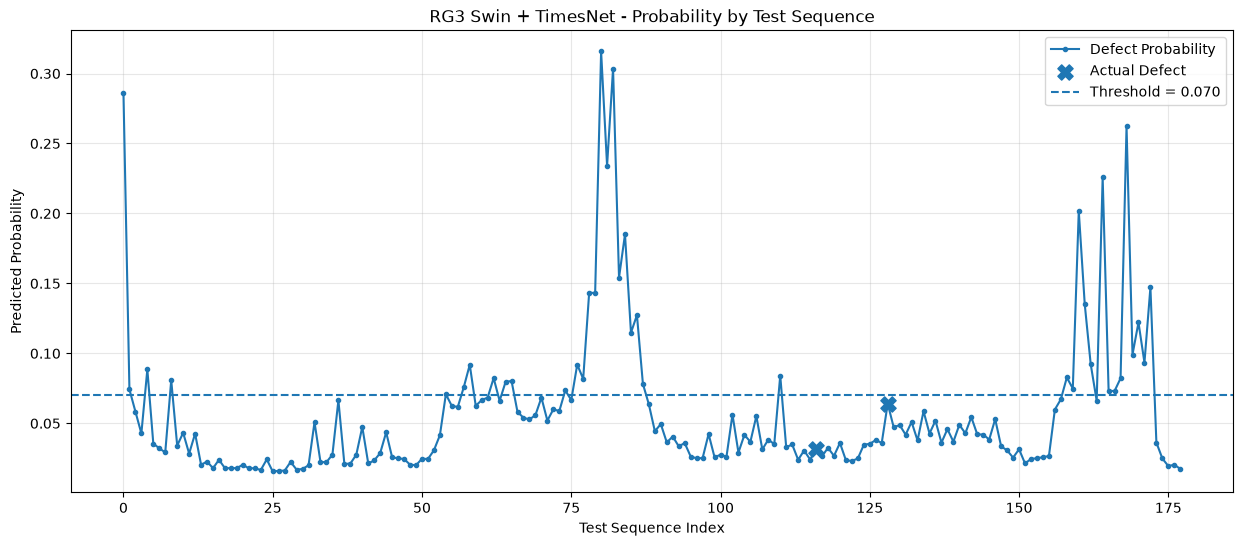

In [6]:
plt.figure(figsize=(15, 6))

plt.plot(
    np.arange(len(test_prob)),
    test_prob,
    marker="o",
    markersize=3,
    label="Defect Probability"
)

defect_idx = np.where(test_true == 1)[0]

plt.scatter(
    defect_idx,
    test_prob[defect_idx],
    s=120,
    marker="X",
    label="Actual Defect"
)

plt.axhline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {BEST_THRESHOLD:.3f}"
)

plt.xlabel("Test Sequence Index")
plt.ylabel("Predicted Probability")
plt.title("RG3 Swin + TimesNet - Probability by Test Sequence")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
check_df = pd.DataFrame({
    "idx": np.arange(len(test_true)),
    "True": test_true.astype(int),
    "Probability": test_prob,
    "Pred": test_pred
})

for defect_idx in np.where(test_true == 1)[0]:

    print("\n" + "=" * 70)
    print(f"Actual defect index = {defect_idx}")
    print("=" * 70)

    start = max(
        0,
        defect_idx - 10
    )

    end = min(
        len(check_df),
        defect_idx + 11
    )

    display(
        check_df.iloc[start:end]
    )


Actual defect index = 116


,idx,True,Probability,Pred
106,106,0,0.055198,0
107,107,0,0.031329,0
108,108,0,0.038389,0
109,109,0,0.035109,0
110,110,0,0.084104,1
111,111,0,0.032881,0
112,112,0,0.034906,0
113,113,0,0.023982,0
114,114,0,0.030565,0
115,115,0,0.024147,0



Actual defect index = 128


,idx,True,Probability,Pred
118,118,0,0.032516,0
119,119,0,0.026745,0
120,120,0,0.035962,0
121,121,0,0.023602,0
122,122,0,0.023109,0
123,123,0,0.024888,0
124,124,0,0.034689,0
125,125,0,0.035368,0
126,126,0,0.038023,0
127,127,0,0.036012,0


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

In [9]:
from torch.utils.data import WeightedRandomSampler


# 각 class 개수
class_counts = np.bincount(y_train)

print("Class Counts:", class_counts)


# class inverse frequency
class_weights = 1.0 / class_counts


# 각 sample weight
sample_weights = class_weights[y_train]


sampler = WeightedRandomSampler(
    weights=torch.tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(sample_weights),
    replacement=True
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0
)

Class Counts: [793  19]


DEVICE: cpu

RAW DATA
Shape: (1182, 26)

Columns:
['Unnamed: 0', 'PassOrFail', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

Target:
PassOrFail
0    1157
1      25
Name: count, dtype: int64

현재 CSV 행 순서를 생산 순서로 사용합니다.

Detected time: None

전체 데이터를 하나의 생산 sequence로 봅니다.

Side encoding:
0 -> ALL

BASE FEATURES
Initial: 24

ROW SPLIT
Train: 0 ~ 826
Val: 827 ~ 1003
Test: 1004 ~ 1181

Active base features: 23
 - Injection_Time
 - Filling_Time
 - Plasticizing_Time
 - Cycle_Time
 - Clamp_Close_Time
 - Cushion_Position


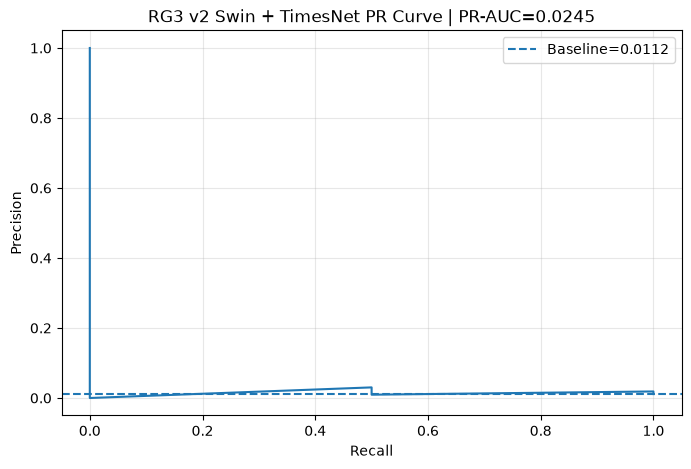

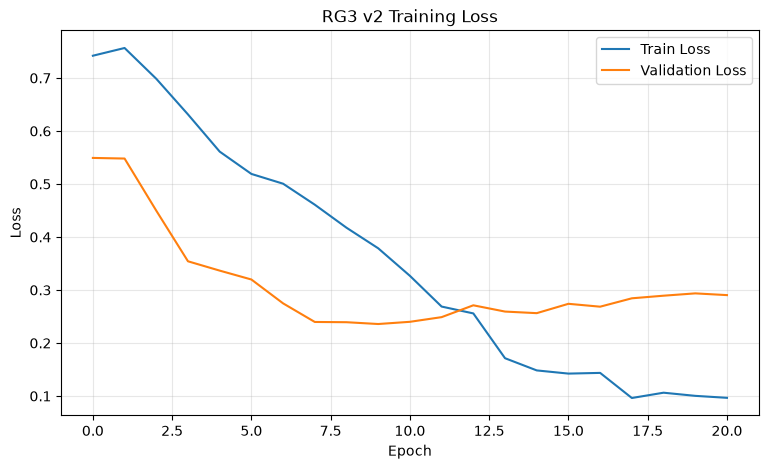

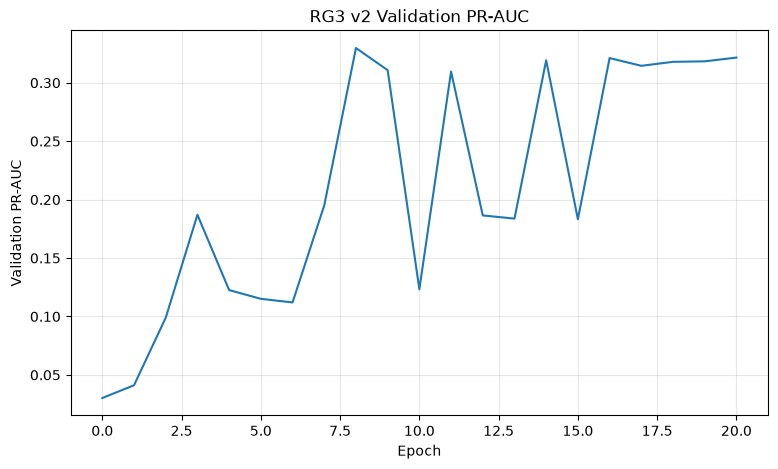

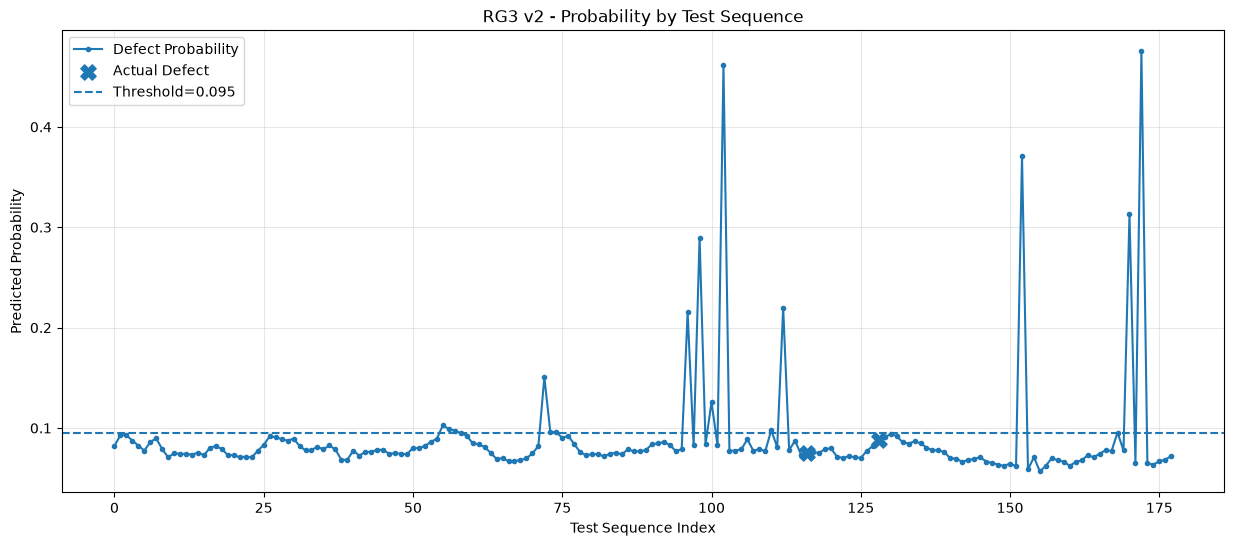


Actual Defect Sequence: 116
 Sequence_Index  True  Probability  Pred  Gate_TimesNet
            106     0     0.088859     0       0.432405
            107     0     0.077295     0       0.430147
            108     0     0.079041     0       0.434037
            109     0     0.076894     0       0.429385
            110     0     0.097887     1       0.429265
            111     0     0.080922     0       0.422619
            112     0     0.219569     1       0.439455
            113     0     0.078150     0       0.418421
            114     0     0.087406     0       0.421975
            115     0     0.073423     0       0.420727
            116     1     0.075316     0       0.423395
            117     0     0.076027     0       0.428571
            118     0     0.075216     0       0.430196
            119     0     0.079089     0       0.434302
            120     0     0.079813     0       0.430905
            121     0     0.071643     0       0.431510
            122    

In [11]:
# ============================================================
# RG3 v2
# Micro Swin + Tiny TimesNet + Gated Fusion
#
# 핵심 변경점
# ------------------------------------------------------------
# 1. Supervised SelectKBest 제거
#    -> Train 불량 19개 수준에서 ANOVA selection 불안정 방지
#
# 2. Swin 입력을 진짜 3채널화
#    Channel 1 = Raw sensor
#    Channel 2 = Diff
#    Channel 3 = Rolling baseline deviation
#
# 3. Tiny TimesNet
#    -> 기존보다 훨씬 작은 모델
#
# 4. Micro Swin
#    -> 기존 Swin보다 축소
#
# 5. Gated Fusion
#    -> TimesNet / Swin 중 어느 feature를 더 믿을지 학습
#
# 6. WeightedRandomSampler
#    -> 불량 sample이 batch에서 너무 드물게 나타나는 문제 완화
#
# 7. BCE / Focal Loss 선택 가능
#
# 8. PR-AUC 기준 Early Stopping
#
# 9. Threshold F2 최적화
#
# 10. Recall@Top-K / Precision@Top-K 추가
#
# 11. Test probability sequence plot
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import os
import copy
import math
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from torchvision.models.swin_transformer import SwinTransformer


warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

SEED = 42

CSV_PATH = r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3.csv"

TARGET = "PassOrFail"

# 파일에 Side가 있으면 자동 사용
SIDE_COL = "Side"

# ------------------------------------------------------------
# 실험 1
# 8부터 추천
#
# 이후
# SEQ_LEN = 16
# 으로 비교
# ------------------------------------------------------------

SEQ_LEN = 8


# ------------------------------------------------------------
# 0 = 현재 cycle 불량 분류
#
# 1 = 다음 cycle 불량 예측
# ------------------------------------------------------------

PREDICT_HORIZON = 0


# ------------------------------------------------------------
# 일단 기존 결과와 직접 비교하기 위해
# 70 / 15 / 15 유지
# ------------------------------------------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15


# ------------------------------------------------------------
# Loss
#
# "bce"
# "focal"
#
# 처음은 BCE 추천
# ------------------------------------------------------------

LOSS_TYPE = "bce"


# ------------------------------------------------------------
# WeightedRandomSampler와 함께 사용하므로
# 기존 20 -> 3
# ------------------------------------------------------------

POS_WEIGHT = 3.0


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

BATCH_SIZE = 32

EPOCHS = 80

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 12


# ------------------------------------------------------------
# Swin
# ------------------------------------------------------------

SWIN_IMAGE_SIZE = 64

SWIN_OUTPUT_DIM = 48


# ------------------------------------------------------------
# TimesNet
# ------------------------------------------------------------

TIMES_D_MODEL = 16

TIMES_LAYERS = 1

TIMES_TOP_K = 2


# ------------------------------------------------------------
# Fusion
# ------------------------------------------------------------

FUSION_DIM = 32

SIDE_EMBED_DIM = 4


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("DEVICE:", DEVICE)


# ============================================================
# 2. SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 3. LOAD
# ============================================================

df = pd.read_csv(CSV_PATH)


print("\n" + "=" * 75)
print("RAW DATA")
print("=" * 75)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget:")
print(df[TARGET].value_counts(dropna=False))


# ============================================================
# 4. TARGET NORMALIZE
# ============================================================

def normalize_target(series):

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    numeric_unique = set(
        numeric.dropna().unique()
    )

    if numeric_unique.issubset({0, 1}):

        return numeric.astype("Int64")

    mapping = {

        "pass": 0,
        "normal": 0,
        "ok": 0,
        "good": 0,

        "fail": 1,
        "defect": 1,
        "ng": 1,
        "bad": 1,
    }

    result = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

    if result.isna().any():

        raise ValueError(
            f"Target 변환 실패: {series.unique()}"
        )

    return result.astype(int)


df[TARGET] = normalize_target(
    df[TARGET]
)


# ============================================================
# 5. TIME SORT
# ============================================================

TIME_CANDIDATES = [

    "timestamp",
    "Timestamp",

    "datetime",
    "Datetime",
    "DateTime",

    "PART_FACT_PLAN_DATE",

    "time",
    "Time",

    "date",
    "Date",
]


def chronological_sort(data):

    data = data.copy()

    detected = None

    for col in TIME_CANDIDATES:

        if col not in data.columns:
            continue

        parsed = pd.to_datetime(
            data[col],
            errors="coerce"
        )

        # 너무 적게 인식되면 시간 컬럼으로 보지 않음
        if parsed.notna().mean() >= 0.8:

            data["__time__"] = parsed

            detected = col

            break

    sort_cols = []

    if detected is not None:

        sort_cols.append("__time__")

    if "PART_FACT_SERIAL" in data.columns:

        sort_cols.append(
            "PART_FACT_SERIAL"
        )

    if sort_cols:

        data = (
            data
            .sort_values(
                sort_cols
            )
            .reset_index(
                drop=True
            )
        )

    else:

        print(
            "\nWARNING:"
            " 시간 컬럼이 없습니다."
        )

        print(
            "현재 CSV 행 순서를 "
            "생산 순서로 사용합니다."
        )

        data = data.reset_index(
            drop=True
        )

    return data, detected


df, detected_time = chronological_sort(
    df
)


print(
    "\nDetected time:",
    detected_time
)


# ============================================================
# 6. SIDE
# ============================================================

if SIDE_COL in df.columns:

    side_text = (
        df[SIDE_COL]
        .astype(str)
        .str.upper()
        .str.strip()
    )

else:

    print(
        "\nWARNING:"
        " Side가 없습니다."
    )

    print(
        "전체 데이터를 하나의 생산 sequence로 봅니다."
    )

    df[SIDE_COL] = "ALL"

    side_text = df[SIDE_COL]


side_codes, side_names = (
    pd.factorize(
        side_text
    )
)


df["__side_code__"] = (
    side_codes
)


NUM_SIDES = max(
    len(side_names),
    1
)


print("\nSide encoding:")

for i, name in enumerate(
    side_names
):

    print(
        i,
        "->",
        name
    )


# ============================================================
# 7. LABEL
# ============================================================

if PREDICT_HORIZON == 0:

    df["__label__"] = (
        df[TARGET]
        .astype(float)
    )

else:

    df["__label__"] = (

        df.groupby(
            "__side_code__",
            sort=False
        )[TARGET]

        .shift(
            -PREDICT_HORIZON
        )

        .astype(float)
    )


# ============================================================
# 8. BASE FEATURES
# ============================================================

META_COLUMNS = {

    TARGET,
    SIDE_COL,

    "__time__",
    "__label__",
    "__side_code__",

    "PART_FACT_SERIAL",
    "PART_FACT_PLAN_DATE",

    "Unnamed: 0",
    "index",
}


# 숫자로 변환 가능한 object 처리
for col in df.columns:

    if col in META_COLUMNS:
        continue

    if df[col].dtype == "object":

        temp = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        if (
            temp.notna().mean()
            >= 0.95
        ):

            df[col] = temp


BASE_FEATURES = [

    col

    for col in df.columns

    if (
        col not in META_COLUMNS

        and

        pd.api.types
        .is_numeric_dtype(
            df[col]
        )
    )
]


print("\n" + "=" * 75)
print("BASE FEATURES")
print("=" * 75)

print(
    "Initial:",
    len(BASE_FEATURES)
)


# ============================================================
# 9. SPLIT BOUNDARY
# ============================================================

N = len(df)

TRAIN_END = int(
    N * TRAIN_RATIO
)

VAL_END = int(
    N * (
        TRAIN_RATIO
        + VAL_RATIO
    )
)


row_index = np.arange(
    N
)


train_row_mask = (
    row_index
    < TRAIN_END
)


valid_label_mask = (
    df["__label__"]
    .notna()
    .values
)


fit_mask = (
    train_row_mask
    &
    valid_label_mask
)


print("\n" + "=" * 75)
print("ROW SPLIT")
print("=" * 75)

print(
    "Train:",
    0,
    "~",
    TRAIN_END - 1
)

print(
    "Val:",
    TRAIN_END,
    "~",
    VAL_END - 1
)

print(
    "Test:",
    VAL_END,
    "~",
    N - 1
)


# ============================================================
# 10. REMOVE CONSTANT FEATURES
# ============================================================

active_features = []


for col in BASE_FEATURES:

    train_values = (
        df.loc[
            fit_mask,
            col
        ]
        .dropna()
    )

    if train_values.nunique() > 1:

        active_features.append(
            col
        )


BASE_FEATURES = (
    active_features
)


print(
    "\nActive base features:",
    len(BASE_FEATURES)
)

for col in BASE_FEATURES:

    print(
        " -",
        col
    )


# ============================================================
# 11. FEATURE ENGINEERING
# ============================================================
#
# TimesNet:
#
# raw
# lag1
# diff1
# roll3_mean
# roll5_mean
# roll5_std
# rolling_deviation
#
# 모든 rolling은 과거 데이터만 사용
# ============================================================

def make_engineered_features(
    data,
    features
):

    output = data.copy()

    engineered = {}

    for col in features:

        grouped = (
            output.groupby(
                "__side_code__",
                sort=False
            )[col]
        )

        # raw는 이미 원본에 존재

        engineered[
            f"{col}_lag1"
        ] = grouped.shift(1)

        engineered[
            f"{col}_diff1"
        ] = grouped.diff(1)

        roll3 = (
            output.groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    3,
                    min_periods=1
                )
                .mean()
            )
        )

        roll5 = (
            output.groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    5,
                    min_periods=1
                )
                .mean()
            )
        )

        roll5_std = (
            output.groupby(
                "__side_code__",
                sort=False
            )[col]
            .transform(
                lambda x:
                x.shift(1)
                .rolling(
                    5,
                    min_periods=2
                )
                .std()
            )
        )

        engineered[
            f"{col}_roll3_mean"
        ] = roll3

        engineered[
            f"{col}_roll5_mean"
        ] = roll5

        engineered[
            f"{col}_roll5_std"
        ] = roll5_std

        # 현재값 - 과거 5개 평균
        engineered[
            f"{col}_roll5_dev"
        ] = (
            output[col]
            - roll5
        )

    engineered_df = pd.DataFrame(
        engineered,
        index=output.index
    )

    output = pd.concat(
        [
            output,
            engineered_df
        ],
        axis=1
    )

    return output


df = make_engineered_features(
    df,
    BASE_FEATURES
)


TIMES_FEATURES = []


for col in BASE_FEATURES:

    TIMES_FEATURES.extend(
        [
            col,

            f"{col}_lag1",

            f"{col}_diff1",

            f"{col}_roll3_mean",

            f"{col}_roll5_mean",

            f"{col}_roll5_std",

            f"{col}_roll5_dev",
        ]
    )


print("\n" + "=" * 75)
print("TIMESNET FEATURES")
print("=" * 75)

print(
    "Total:",
    len(TIMES_FEATURES)
)


# ============================================================
# 12. SWIN 3 CHANNEL
# ============================================================
#
# Channel 1:
# raw
#
# Channel 2:
# diff1
#
# Channel 3:
# raw - past rolling5 mean
# ============================================================

RAW_FEATURES = (
    BASE_FEATURES.copy()
)

DIFF_FEATURES = [

    f"{col}_diff1"

    for col in BASE_FEATURES
]

DEV_FEATURES = [

    f"{col}_roll5_dev"

    for col in BASE_FEATURES
]


# ============================================================
# 13. PREPROCESSOR
# ============================================================

class ArrayPreprocessor:

    def __init__(self):

        self.imputer = (
            SimpleImputer(
                strategy="median"
            )
        )

        self.scaler = (
            StandardScaler()
        )

    def fit(
        self,
        X
    ):

        X = self.imputer.fit_transform(
            X
        )

        self.scaler.fit(
            X
        )

        return self

    def transform(
        self,
        X
    ):

        X = self.imputer.transform(
            X
        )

        X = self.scaler.transform(
            X
        )

        return X.astype(
            np.float32
        )


# ============================================================
# 14. TIMES PREPROCESSING
# ============================================================

times_df = (
    df[TIMES_FEATURES]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# supervised feature selection 안 함
# 대신 constant/near constant만 제거

keep_times_features = []


for col in TIMES_FEATURES:

    train_values = (
        times_df.loc[
            fit_mask,
            col
        ]
        .dropna()
    )

    if train_values.nunique() > 1:

        keep_times_features.append(
            col
        )


TIMES_FEATURES = (
    keep_times_features
)


times_preprocessor = (
    ArrayPreprocessor()
)


times_preprocessor.fit(

    df.loc[
        fit_mask,
        TIMES_FEATURES
    ]
)


X_times_all = (
    times_preprocessor.transform(
        df[
            TIMES_FEATURES
        ]
    )
)


print(
    "\nTimesNet input features:",
    X_times_all.shape[1]
)


# ============================================================
# 15. SWIN PREPROCESSING
# ============================================================

raw_preprocessor = (
    ArrayPreprocessor()
)

diff_preprocessor = (
    ArrayPreprocessor()
)

dev_preprocessor = (
    ArrayPreprocessor()
)


raw_preprocessor.fit(

    df.loc[
        fit_mask,
        RAW_FEATURES
    ]
)


diff_preprocessor.fit(

    df.loc[
        fit_mask,
        DIFF_FEATURES
    ]
)


dev_preprocessor.fit(

    df.loc[
        fit_mask,
        DEV_FEATURES
    ]
)


X_raw_all = (
    raw_preprocessor.transform(
        df[
            RAW_FEATURES
        ]
    )
)


X_diff_all = (
    diff_preprocessor.transform(
        df[
            DIFF_FEATURES
        ]
    )
)


X_dev_all = (
    dev_preprocessor.transform(
        df[
            DEV_FEATURES
        ]
    )
)


print(
    "Swin sensors:",
    X_raw_all.shape[1]
)


# ============================================================
# 16. SEQUENCE
# ============================================================

def build_sequences(
    X_times,
    X_raw,
    X_diff,
    X_dev,
    labels,
    side_codes,
    seq_len,
):

    times_sequences = []

    swin_sequences = []

    ys = []

    sides = []

    end_indices = []


    unique_sides = np.unique(
        side_codes
    )


    for side in unique_sides:

        positions = np.where(
            side_codes == side
        )[0]

        for j in range(
            seq_len - 1,
            len(positions)
        ):

            end_idx = (
                positions[j]
            )

            if np.isnan(
                labels[end_idx]
            ):

                continue

            seq_indices = positions[
                j - seq_len + 1
                :
                j + 1
            ]


            # ----------------------------------------
            # TimesNet
            # [T, F]
            # ----------------------------------------

            times_sequences.append(
                X_times[
                    seq_indices
                ]
            )


            # ----------------------------------------
            # Swin
            #
            # raw:
            # [T,F] -> [F,T]
            #
            # 3개 channel stack
            #
            # [3,F,T]
            # ----------------------------------------

            raw_map = (
                X_raw[
                    seq_indices
                ].T
            )

            diff_map = (
                X_diff[
                    seq_indices
                ].T
            )

            dev_map = (
                X_dev[
                    seq_indices
                ].T
            )


            swin_map = np.stack(
                [
                    raw_map,
                    diff_map,
                    dev_map,
                ],
                axis=0
            )


            swin_sequences.append(
                swin_map
            )


            ys.append(
                int(
                    labels[end_idx]
                )
            )

            sides.append(
                int(side)
            )

            end_indices.append(
                int(end_idx)
            )


    return (

        np.asarray(
            times_sequences,
            dtype=np.float32
        ),

        np.asarray(
            swin_sequences,
            dtype=np.float32
        ),

        np.asarray(
            ys,
            dtype=np.int64
        ),

        np.asarray(
            sides,
            dtype=np.int64
        ),

        np.asarray(
            end_indices,
            dtype=np.int64
        ),
    )


(
    X_times_seq,
    X_swin_seq,
    y_seq,
    side_seq,
    end_seq,
) = build_sequences(

    X_times=
        X_times_all,

    X_raw=
        X_raw_all,

    X_diff=
        X_diff_all,

    X_dev=
        X_dev_all,

    labels=
        df["__label__"]
        .values,

    side_codes=
        df["__side_code__"]
        .values,

    seq_len=
        SEQ_LEN,
)


print("\n" + "=" * 75)
print("SEQUENCE")
print("=" * 75)

print(
    "TimesNet:",
    X_times_seq.shape
)

print(
    "Swin:",
    X_swin_seq.shape
)

print(
    "Target:",
    y_seq.shape
)


# ============================================================
# 17. SEQUENCE SPLIT
# ============================================================

train_mask = (
    end_seq
    < TRAIN_END
)

val_mask = (
    (end_seq >= TRAIN_END)
    &
    (end_seq < VAL_END)
)

test_mask = (
    end_seq
    >= VAL_END
)


def arr_split(
    arr,
    mask
):

    return arr[mask]


X_times_train = arr_split(
    X_times_seq,
    train_mask
)

X_times_val = arr_split(
    X_times_seq,
    val_mask
)

X_times_test = arr_split(
    X_times_seq,
    test_mask
)


X_swin_train = arr_split(
    X_swin_seq,
    train_mask
)

X_swin_val = arr_split(
    X_swin_seq,
    val_mask
)

X_swin_test = arr_split(
    X_swin_seq,
    test_mask
)


y_train = arr_split(
    y_seq,
    train_mask
)

y_val = arr_split(
    y_seq,
    val_mask
)

y_test = arr_split(
    y_seq,
    test_mask
)


side_train = arr_split(
    side_seq,
    train_mask
)

side_val = arr_split(
    side_seq,
    val_mask
)

side_test = arr_split(
    side_seq,
    test_mask
)


end_train = arr_split(
    end_seq,
    train_mask
)

end_val = arr_split(
    end_seq,
    val_mask
)

end_test = arr_split(
    end_seq,
    test_mask
)


# ============================================================
# 18. SPLIT INFO
# ============================================================

def show_split(
    name,
    target
):

    n = len(target)

    normal = int(
        (target == 0)
        .sum()
    )

    defect = int(
        (target == 1)
        .sum()
    )

    rate = (
        defect / n
        if n > 0
        else 0
    )

    print(
        f"{name:5s} | "
        f"N={n:4d} | "
        f"Normal={normal:4d} | "
        f"Defect={defect:3d} | "
        f"Rate={rate:.4f}"
    )


print("\n" + "=" * 75)
print("WINDOW SPLIT")
print("=" * 75)

show_split(
    "Train",
    y_train
)

show_split(
    "Val",
    y_val
)

show_split(
    "Test",
    y_test
)


if (
    (y_val == 1).sum() < 3
    or
    (y_test == 1).sum() < 3
):

    print(
        "\nWARNING:"
        " Validation/Test 불량 수가 매우 적습니다."
    )

    print(
        "PR-AUC의 분산이 매우 클 수 있습니다."
    )


# ============================================================
# 19. DATASET
# ============================================================

class RG3Dataset(Dataset):

    def __init__(
        self,
        times,
        swin,
        side,
        target
    ):

        self.times = torch.tensor(
            times,
            dtype=torch.float32
        )

        self.swin = torch.tensor(
            swin,
            dtype=torch.float32
        )

        self.side = torch.tensor(
            side,
            dtype=torch.long
        )

        self.target = torch.tensor(
            target,
            dtype=torch.float32
        )

    def __len__(
        self
    ):

        return len(
            self.target
        )

    def __getitem__(
        self,
        idx
    ):

        return (

            self.times[idx],

            self.swin[idx],

            self.side[idx],

            self.target[idx],
        )


train_dataset = RG3Dataset(

    X_times_train,
    X_swin_train,
    side_train,
    y_train,
)


val_dataset = RG3Dataset(

    X_times_val,
    X_swin_val,
    side_val,
    y_val,
)


test_dataset = RG3Dataset(

    X_times_test,
    X_swin_test,
    side_test,
    y_test,
)


# ============================================================
# 20. WEIGHTED RANDOM SAMPLER
# ============================================================
#
# 완전 50:50 oversampling은 과할 수 있음
#
# inverse sqrt frequency 사용
#
# 기존 2% -> batch에서 대략 10~15% 수준으로 증가
# ============================================================

class_counts = np.bincount(
    y_train,
    minlength=2
)


print(
    "\nClass counts:",
    class_counts
)


class_weights = (
    1.0 /
    np.sqrt(
        np.maximum(
            class_counts,
            1
        )
    )
)


sample_weights = (
    class_weights[
        y_train
    ]
)


sampler = (
    WeightedRandomSampler(

        weights=torch.tensor(
            sample_weights,
            dtype=torch.double
        ),

        num_samples=len(
            sample_weights
        ),

        replacement=True,
    )
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    sampler=
        sampler,

    num_workers=
        0,
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


# ============================================================
# 21. TIMESNET
# ============================================================

class InceptionBlock2D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            padding=0
        )

        self.conv3 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

    def forward(
        self,
        x
    ):

        return (
            self.conv1(x)
            +
            self.conv3(x)
        ) / 2


# ============================================================
# FFT
# ============================================================

def FFT_for_Period(
    x,
    k=2
):

    # x:
    # [B,T,C]

    xf = torch.fft.rfft(
        x,
        dim=1
    )


    freq_strength = (

        xf.abs()

        .mean(
            dim=0
        )

        .mean(
            dim=-1
        )
    )


    # DC 제거
    freq_strength[0] = (
        -torch.inf
    )


    valid_k = min(

        k,

        max(
            1,
            len(freq_strength) - 1
        )
    )


    top_indices = torch.topk(
        freq_strength,
        valid_k
    ).indices


    T = x.size(1)


    periods = []


    for idx in top_indices:

        freq_idx = max(
            1,
            int(
                idx.item()
            )
        )

        period = max(
            1,
            T // freq_idx
        )

        periods.append(
            period
        )


    weights = (

        xf.abs()

        .mean(
            dim=-1
        )[
            :,
            top_indices
        ]
    )


    return (
        periods,
        weights
    )


# ============================================================
# TIMES BLOCK
# ============================================================

class TinyTimesBlock(nn.Module):

    def __init__(
        self,
        d_model,
        top_k=2
    ):

        super().__init__()

        self.top_k = (
            top_k
        )

        self.conv = nn.Sequential(

            InceptionBlock2D(
                d_model,
                d_model
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),

            InceptionBlock2D(
                d_model,
                d_model
            ),
        )

    def forward(
        self,
        x
    ):

        B, T, C = x.shape


        periods, weights = (
            FFT_for_Period(
                x,
                self.top_k
            )
        )


        results = []


        for period in periods:

            target_len = (
                math.ceil(
                    T / period
                )
                * period
            )


            if target_len > T:

                pad = torch.zeros(

                    B,

                    target_len - T,

                    C,

                    device=x.device,

                    dtype=x.dtype,
                )


                x_pad = torch.cat(
                    [
                        x,
                        pad
                    ],
                    dim=1
                )

            else:

                x_pad = x


            # [B,T,C]
            # ->
            # [B,C,rows,period]

            temp = x_pad.reshape(

                B,

                target_len // period,

                period,

                C
            )


            temp = temp.permute(
                0,
                3,
                1,
                2
            ).contiguous()


            temp = self.conv(
                temp
            )


            # 다시 sequence

            temp = temp.permute(
                0,
                2,
                3,
                1
            ).reshape(
                B,
                target_len,
                C
            )


            temp = temp[
                :,
                :T,
                :
            ]


            results.append(
                temp
            )


        results = torch.stack(
            results,
            dim=-1
        )


        weights = F.softmax(
            weights,
            dim=1
        )


        weights = (
            weights
            .unsqueeze(1)
            .unsqueeze(1)
        )


        result = (
            results
            * weights
        ).sum(
            dim=-1
        )


        return (
            result
            +
            x
        )


# ============================================================
# TIMESNET ENCODER
# ============================================================

class TinyTimesNetEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model=16,
        layers=1,
        top_k=2
    ):

        super().__init__()


        self.input_projection = (
            nn.Sequential(

                nn.Linear(
                    input_dim,
                    d_model
                ),

                nn.LayerNorm(
                    d_model
                ),
            )
        )


        self.blocks = nn.ModuleList(

            [

                TinyTimesBlock(
                    d_model=d_model,
                    top_k=top_k
                )

                for _ in range(
                    layers
                )
            ]
        )


        self.norms = nn.ModuleList(

            [

                nn.LayerNorm(
                    d_model
                )

                for _ in range(
                    layers
                )
            ]
        )


        self.dropout = nn.Dropout(
            0.15
        )


    def forward(
        self,
        x
    ):

        x = self.input_projection(
            x
        )


        for block, norm in zip(
            self.blocks,
            self.norms
        ):

            x = block(
                x
            )

            x = norm(
                x
            )

            x = self.dropout(
                x
            )


        # mean + max pooling
        mean_pool = x.mean(
            dim=1
        )

        max_pool = x.max(
            dim=1
        ).values


        feature = (
            mean_pool
            +
            max_pool
        ) / 2


        return feature


# ============================================================
# 22. MICRO SWIN
# ============================================================

class MicroSwinEncoder(nn.Module):

    def __init__(
        self,
        output_dim=48,
        image_size=64
    ):

        super().__init__()


        self.image_size = (
            image_size
        )


        self.swin = (
            SwinTransformer(

                patch_size=[
                    4,
                    4
                ],

                embed_dim=16,

                depths=[
                    1,
                    1,
                    1
                ],

                num_heads=[
                    2,
                    4,
                    8
                ],

                window_size=[
                    4,
                    4
                ],

                mlp_ratio=2.0,

                dropout=0.10,

                attention_dropout=0.10,

                stochastic_depth_prob=0.05,

                num_classes=
                    output_dim,
            )
        )


    def forward(
        self,
        x
    ):

        # 이미
        #
        # [B,3,Sensor,Time]

        x = F.interpolate(

            x,

            size=(
                self.image_size,
                self.image_size
            ),

            mode="bilinear",

            align_corners=False,
        )


        return self.swin(
            x
        )


# ============================================================
# 23. GATED FUSION
# ============================================================

class GatedFusionModel(nn.Module):

    def __init__(
        self,
        times_input_dim,
        num_sides
    ):

        super().__init__()


        # ----------------------------------------
        # TimesNet
        # ----------------------------------------

        self.timesnet = (
            TinyTimesNetEncoder(

                input_dim=
                    times_input_dim,

                d_model=
                    TIMES_D_MODEL,

                layers=
                    TIMES_LAYERS,

                top_k=
                    TIMES_TOP_K,
            )
        )


        # ----------------------------------------
        # Swin
        # ----------------------------------------

        self.swin = (
            MicroSwinEncoder(

                output_dim=
                    SWIN_OUTPUT_DIM,

                image_size=
                    SWIN_IMAGE_SIZE,
            )
        )


        # ----------------------------------------
        # 두 branch를 동일 차원으로 projection
        # ----------------------------------------

        self.times_projection = (
            nn.Sequential(

                nn.Linear(
                    TIMES_D_MODEL,
                    FUSION_DIM
                ),

                nn.LayerNorm(
                    FUSION_DIM
                ),

                nn.GELU()
            )
        )


        self.swin_projection = (
            nn.Sequential(

                nn.Linear(
                    SWIN_OUTPUT_DIM,
                    FUSION_DIM
                ),

                nn.LayerNorm(
                    FUSION_DIM
                ),

                nn.GELU()
            )
        )


        # ----------------------------------------
        # Side embedding
        # ----------------------------------------

        self.side_embedding = (
            nn.Embedding(

                max(
                    num_sides,
                    1
                ),

                SIDE_EMBED_DIM
            )
        )


        # ----------------------------------------
        # Gate
        #
        # sigmoid
        #
        # 1 -> TimesNet 쪽 비중 증가
        # 0 -> Swin 쪽 비중 증가
        # ----------------------------------------

        gate_input_dim = (

            FUSION_DIM
            * 2

            +

            SIDE_EMBED_DIM
        )


        self.gate = nn.Sequential(

            nn.Linear(
                gate_input_dim,
                FUSION_DIM
            ),

            nn.Sigmoid()
        )


        # ----------------------------------------
        # classifier
        # ----------------------------------------

        classifier_input = (

            FUSION_DIM

            +

            SIDE_EMBED_DIM
        )


        self.classifier = nn.Sequential(

            nn.LayerNorm(
                classifier_input
            ),

            nn.Linear(
                classifier_input,
                24
            ),

            nn.GELU(),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                24,
                12
            ),

            nn.GELU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                12,
                1
            )
        )


    def forward(
        self,
        x_times,
        x_swin,
        side,
        return_gate=False
    ):

        # TimesNet
        t = self.timesnet(
            x_times
        )


        # Swin
        s = self.swin(
            x_swin
        )


        t = self.times_projection(
            t
        )


        s = self.swin_projection(
            s
        )


        side_emb = (
            self.side_embedding(
                side
            )
        )


        gate_input = torch.cat(
            [
                t,
                s,
                side_emb
            ],
            dim=1
        )


        g = self.gate(
            gate_input
        )


        # gated fusion
        fused = (

            g * t

            +

            (1 - g) * s
        )


        final_feature = torch.cat(
            [
                fused,
                side_emb
            ],
            dim=1
        )


        logits = (
            self.classifier(
                final_feature
            )
            .squeeze(1)
        )


        if return_gate:

            return (
                logits,
                g
            )


        return logits


# ============================================================
# 24. MODEL
# ============================================================

model = GatedFusionModel(

    times_input_dim=
        X_times_train.shape[-1],

    num_sides=
        NUM_SIDES

).to(
    DEVICE
)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print("\n" + "=" * 75)
print("MODEL")
print("=" * 75)

print(
    "Total params:",
    f"{total_params:,}"
)

print(
    "Trainable:",
    f"{trainable_params:,}"
)


# ============================================================
# 25. LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.75,
        gamma=2.0
    ):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma


    def forward(
        self,
        logits,
        targets
    ):

        bce = (
            F.binary_cross_entropy_with_logits(

                logits,
                targets,

                reduction="none"
            )
        )


        prob = torch.sigmoid(
            logits
        )


        pt = torch.where(

            targets == 1,

            prob,

            1 - prob
        )


        alpha_t = torch.where(

            targets == 1,

            torch.full_like(
                targets,
                self.alpha
            ),

            torch.full_like(
                targets,
                1 - self.alpha
            )
        )


        loss = (

            alpha_t

            *

            (1 - pt).pow(
                self.gamma
            )

            *

            bce
        )


        return loss.mean()


if LOSS_TYPE.lower() == "focal":

    criterion = FocalLoss(

        alpha=0.75,

        gamma=2.0
    )

    print(
        "\nLoss: Focal Loss"
    )

else:

    criterion = (
        nn.BCEWithLogitsLoss(

            pos_weight=torch.tensor(

                [POS_WEIGHT],

                dtype=torch.float32,

                device=DEVICE
            )
        )
    )

    print(
        f"\nLoss: BCE | "
        f"pos_weight={POS_WEIGHT}"
    )


# ============================================================
# 26. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,
)


scheduler = (

    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=3,

        min_lr=1e-6,
    )
)


# ============================================================
# 27. METRIC HELPERS
# ============================================================

def safe_pr_auc(
    y_true,
    prob
):

    if len(
        np.unique(
            y_true
        )
    ) < 2:

        return np.nan


    return average_precision_score(
        y_true,
        prob
    )


def safe_roc_auc(
    y_true,
    prob
):

    if len(
        np.unique(
            y_true
        )
    ) < 2:

        return np.nan


    return roc_auc_score(
        y_true,
        prob
    )


# ============================================================
# 28. PREDICT
# ============================================================

@torch.no_grad()
def predict_loader(
    model,
    loader,
    criterion=None,
    return_gate=False
):

    model.eval()


    all_true = []

    all_prob = []

    all_gate = []


    running_loss = 0

    total = 0


    for (
        x_times,
        x_swin,
        side,
        y
    ) in loader:


        x_times = x_times.to(
            DEVICE
        )

        x_swin = x_swin.to(
            DEVICE
        )

        side = side.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )


        if return_gate:

            logits, gate = model(

                x_times,
                x_swin,
                side,

                return_gate=True
            )

            all_gate.append(

                gate.cpu().numpy()
            )

        else:

            logits = model(

                x_times,
                x_swin,
                side
            )


        if criterion is not None:

            loss = criterion(
                logits,
                y
            )

            running_loss += (
                loss.item()
                * len(y)
            )

            total += (
                len(y)
            )


        prob = torch.sigmoid(
            logits
        )


        all_true.append(
            y.cpu().numpy()
        )

        all_prob.append(
            prob.cpu().numpy()
        )


    y_true = np.concatenate(
        all_true
    )

    prob = np.concatenate(
        all_prob
    )


    avg_loss = (

        running_loss / total

        if total > 0

        else np.nan
    )


    if return_gate:

        gates = np.concatenate(
            all_gate,
            axis=0
        )

        return (
            avg_loss,
            y_true,
            prob,
            gates
        )


    return (
        avg_loss,
        y_true,
        prob
    )


# ============================================================
# 29. TRAIN
# ============================================================

best_pr_auc = -np.inf

best_state = None

patience_counter = 0


history = {

    "train_loss": [],

    "val_loss": [],

    "val_pr_auc": [],
}


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()


    train_loss_sum = 0

    train_count = 0


    for (
        x_times,
        x_swin,
        side,
        y
    ) in train_loader:


        x_times = x_times.to(
            DEVICE
        )

        x_swin = x_swin.to(
            DEVICE
        )

        side = side.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(

            x_times,
            x_swin,
            side
        )


        loss = criterion(
            logits,
            y
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0
        )


        optimizer.step()


        train_loss_sum += (
            loss.item()
            * len(y)
        )

        train_count += (
            len(y)
        )


    train_loss = (
        train_loss_sum
        /
        train_count
    )


    (
        val_loss,
        val_true,
        val_prob
    ) = predict_loader(

        model,
        val_loader,
        criterion
    )


    val_pr_auc = safe_pr_auc(
        val_true,
        val_prob
    )


    # validation에 2 class가 없으면 loss 사용
    if np.isnan(
        val_pr_auc
    ):

        monitor_score = (
            -val_loss
        )

    else:

        monitor_score = (
            val_pr_auc
        )


    scheduler.step(
        monitor_score
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "val_pr_auc"
    ].append(
        val_pr_auc
    )


    print(

        f"Epoch {epoch:03d} | "

        f"Train Loss {train_loss:.5f} | "

        f"Val Loss {val_loss:.5f} | "

        f"Val PR-AUC {val_pr_auc:.5f} | "

        f"LR {current_lr:.2e}"
    )


    if monitor_score > best_pr_auc:

        best_pr_auc = (
            monitor_score
        )

        best_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0


    else:

        patience_counter += 1


        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping."
            )

            break


# ============================================================
# 30. BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


model = model.to(
    DEVICE
)


# ============================================================
# 31. VALIDATION THRESHOLD
# ============================================================

(
    _,
    val_true,
    val_prob
) = predict_loader(

    model,
    val_loader
)


def find_best_threshold(
    y_true,
    prob,
    beta=2
):

    if len(
        np.unique(
            y_true
        )
    ) < 2:

        return (
            0.5,
            np.nan
        )


    best_threshold = (
        0.5
    )

    best_score = (
        -1
    )


    # RG3는 낮은 probability까지 탐색
    thresholds = np.arange(
        0.01,
        0.51,
        0.005
    )


    for threshold in thresholds:

        pred = (
            prob >= threshold
        ).astype(int)


        score = fbeta_score(

            y_true,
            pred,

            beta=beta,

            zero_division=0
        )


        if score > best_score:

            best_score = (
                score
            )

            best_threshold = (
                threshold
            )


    return (
        best_threshold,
        best_score
    )


BEST_THRESHOLD, VAL_F2 = (
    find_best_threshold(

        val_true,
        val_prob,

        beta=2
    )
)


print("\n" + "=" * 75)
print("VALIDATION")
print("=" * 75)

print(
    "PR-AUC:",
    safe_pr_auc(
        val_true,
        val_prob
    )
)

print(
    "Best threshold:",
    BEST_THRESHOLD
)

print(
    "F2:",
    VAL_F2
)


# ============================================================
# 32. TEST
# ============================================================

(
    test_loss,
    test_true,
    test_prob,
    test_gate
) = predict_loader(

    model,
    test_loader,
    criterion,

    return_gate=True
)


test_pred = (

    test_prob
    >= BEST_THRESHOLD

).astype(int)


test_pr_auc = (
    safe_pr_auc(
        test_true,
        test_prob
    )
)


test_roc_auc = (
    safe_roc_auc(
        test_true,
        test_prob
    )
)


test_precision = precision_score(

    test_true,
    test_pred,

    zero_division=0
)


test_recall = recall_score(

    test_true,
    test_pred,

    zero_division=0
)


test_f1 = f1_score(

    test_true,
    test_pred,

    zero_division=0
)


test_f2 = fbeta_score(

    test_true,
    test_pred,

    beta=2,

    zero_division=0
)


baseline_pr = (
    test_true.mean()
)


pr_lift = (

    test_pr_auc
    /
    baseline_pr

    if baseline_pr > 0

    else np.nan
)


print("\n" + "=" * 75)
print("FINAL TEST RESULT")
print("=" * 75)

print(
    f"Threshold      : {BEST_THRESHOLD:.4f}"
)

print(
    f"Loss           : {test_loss:.6f}"
)

print(
    f"PR baseline    : {baseline_pr:.6f}"
)

print(
    f"PR-AUC         : {test_pr_auc:.6f}"
)

print(
    f"PR Lift        : {pr_lift:.2f}x"
)

print(
    f"ROC-AUC        : {test_roc_auc:.6f}"
)

print(
    f"Precision      : {test_precision:.6f}"
)

print(
    f"Recall         : {test_recall:.6f}"
)

print(
    f"F1             : {test_f1:.6f}"
)

print(
    f"F2             : {test_f2:.6f}"
)


print("\nConfusion Matrix")

print(
    confusion_matrix(
        test_true,
        test_pred
    )
)


print("\nClassification Report")

print(

    classification_report(

        test_true,
        test_pred,

        digits=4,

        zero_division=0
    )
)


# ============================================================
# 33. TOP-K RANKING METRIC
# ============================================================
#
# Threshold 외에도
# 위험 사용자/위험 공정 Top-K 관점으로 평가
#
# 극심한 불균형에서는 상당히 중요
# ============================================================

def ranking_metrics(
    y_true,
    prob,
    fractions=(
        0.05,
        0.10,
        0.20
    )
):

    order = np.argsort(
        -prob
    )

    total_positive = int(
        y_true.sum()
    )


    rows = []


    for fraction in fractions:

        k = max(

            1,

            int(
                np.ceil(
                    len(y_true)
                    * fraction
                )
            )
        )


        top_idx = (
            order[:k]
        )


        tp = int(
            y_true[
                top_idx
            ].sum()
        )


        precision = (
            tp / k
        )


        recall = (

            tp
            / total_positive

            if total_positive > 0

            else 0
        )


        rows.append(
            {

                "Top_Fraction":
                    fraction,

                "Top_K":
                    k,

                "TP":
                    tp,

                "Precision":
                    precision,

                "Recall":
                    recall,
            }
        )


    return pd.DataFrame(
        rows
    )


ranking_df = ranking_metrics(

    test_true,
    test_prob
)


print("\n" + "=" * 75)
print("RANKING METRIC")
print("=" * 75)

print(
    ranking_df.to_string(
        index=False
    )
)


# ============================================================
# 34. ACTUAL DEFECT PROBABILITY
# ============================================================

result_df = pd.DataFrame(
    {

        "Sequence_Index":
            np.arange(
                len(test_true)
            ),

        "Row_Index":
            end_test,

        "True":
            test_true.astype(int),

        "Probability":
            test_prob,

        "Pred":
            test_pred,
    }
)


if SIDE_COL in df.columns:

    result_df[
        "Side"
    ] = (
        df.iloc[
            end_test
        ][SIDE_COL]
        .values
    )


if "__time__" in df.columns:

    result_df[
        "Time"
    ] = (
        df.iloc[
            end_test
        ]["__time__"]
        .values
    )


print("\n" + "=" * 75)
print("ACTUAL DEFECT")
print("=" * 75)

print(

    result_df[
        result_df["True"] == 1
    ]

    .sort_values(
        "Probability",
        ascending=False
    )

    .to_string(
        index=False
    )
)


print("\n" + "=" * 75)
print("TOP 30 RISK")
print("=" * 75)

print(

    result_df

    .sort_values(
        "Probability",
        ascending=False
    )

    .head(30)

    .to_string(
        index=False
    )
)


# ============================================================
# 35. GATE ANALYSIS
# ============================================================
#
# gate = 1
# -> TimesNet 선호
#
# gate = 0
# -> Swin 선호
# ============================================================

gate_mean_per_sample = (
    test_gate.mean(
        axis=1
    )
)


result_df[
    "Gate_TimesNet"
] = (
    gate_mean_per_sample
)


print("\n" + "=" * 75)
print("GATE ANALYSIS")
print("=" * 75)

print(
    "Average TimesNet gate:",
    gate_mean_per_sample.mean()
)

print(
    "Average Swin gate:",
    1
    -
    gate_mean_per_sample.mean()
)


if (
    (test_true == 1)
    .sum()
    > 0
):

    print(
        "Defect TimesNet gate:",
        gate_mean_per_sample[
            test_true == 1
        ].mean()
    )


    print(
        "Normal TimesNet gate:",
        gate_mean_per_sample[
            test_true == 0
        ].mean()
    )


# ============================================================
# 36. PR CURVE
# ============================================================

if len(
    np.unique(
        test_true
    )
) >= 2:

    precision_curve, recall_curve, _ = (
        precision_recall_curve(

            test_true,
            test_prob
        )
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        recall_curve,
        precision_curve
    )


    plt.axhline(

        baseline_pr,

        linestyle="--",

        label=(
            f"Baseline={baseline_pr:.4f}"
        )
    )


    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )


    plt.title(

        "RG3 v2 "
        "Swin + TimesNet PR Curve "
        f"| PR-AUC={test_pr_auc:.4f}"
    )


    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()


# ============================================================
# 37. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    history[
        "train_loss"
    ],

    label="Train Loss"
)


plt.plot(

    history[
        "val_loss"
    ],

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "RG3 v2 Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 38. VAL PR-AUC CURVE
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    history[
        "val_pr_auc"
    ]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation PR-AUC"
)

plt.title(
    "RG3 v2 Validation PR-AUC"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 39. TEST PROBABILITY BY SEQUENCE
# ============================================================

plt.figure(
    figsize=(15, 6)
)


plt.plot(

    np.arange(
        len(test_prob)
    ),

    test_prob,

    marker="o",

    markersize=3,

    label="Defect Probability"
)


actual_defect_idx = np.where(
    test_true == 1
)[0]


plt.scatter(

    actual_defect_idx,

    test_prob[
        actual_defect_idx
    ],

    s=120,

    marker="X",

    label="Actual Defect"
)


plt.axhline(

    BEST_THRESHOLD,

    linestyle="--",

    label=(
        f"Threshold="
        f"{BEST_THRESHOLD:.3f}"
    )
)


plt.xlabel(
    "Test Sequence Index"
)

plt.ylabel(
    "Predicted Probability"
)


plt.title(
    "RG3 v2 - Probability by Test Sequence"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 40. DEFECT 주변 확인
# ============================================================

for defect_idx in actual_defect_idx:

    print("\n" + "=" * 75)

    print(
        "Actual Defect Sequence:",
        defect_idx
    )

    print("=" * 75)


    start = max(
        0,
        defect_idx - 10
    )


    end = min(
        len(result_df),
        defect_idx + 11
    )


    print(

        result_df.iloc[
            start:end
        ][
            [
                "Sequence_Index",
                "True",
                "Probability",
                "Pred",
                "Gate_TimesNet",
            ]
        ]

        .to_string(
            index=False
        )
    )


# ============================================================
# 41. SAVE RESULT
# ============================================================

result_df.to_csv(

    "rg3_v2_predictions.csv",

    index=False,

    encoding="utf-8-sig"
)


ranking_df.to_csv(

    "rg3_v2_ranking_metrics.csv",

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 42. SAVE MODEL
# ============================================================

torch.save(

    {

        "model_state_dict":
            model.state_dict(),

        "best_threshold":
            BEST_THRESHOLD,

        "seq_len":
            SEQ_LEN,

        "loss_type":
            LOSS_TYPE,

        "pos_weight":
            POS_WEIGHT,

        "times_features":
            TIMES_FEATURES,

        "base_features":
            BASE_FEATURES,

        "times_input_dim":
            X_times_train.shape[-1],

        "num_sides":
            NUM_SIDES,

        "side_names":
            list(side_names),
    },

    "rg3_v2_swin_timesnet.pt"
)


joblib.dump(

    {

        "times_preprocessor":
            times_preprocessor,

        "raw_preprocessor":
            raw_preprocessor,

        "diff_preprocessor":
            diff_preprocessor,

        "dev_preprocessor":
            dev_preprocessor,

        "base_features":
            BASE_FEATURES,

        "times_features":
            TIMES_FEATURES,

    },

    "rg3_v2_preprocessors.pkl"
)


print("\n" + "=" * 75)
print("SAVED")
print("=" * 75)

print(
    "rg3_v2_predictions.csv"
)

print(
    "rg3_v2_ranking_metrics.csv"
)

print(
    "rg3_v2_swin_timesnet.pt"
)

print(
    "rg3_v2_preprocessors.pkl"
)

In [12]:
# ============================================================
# RG3 ABLATION EXPERIMENT
#
# TimesNet Only vs Swin Only vs Fusion
# ×
# SEQ_LEN = 4 / 8 / 16
#
# Output
# ------------------------------------------------------------
# - Validation PR-AUC
# - Test PR-AUC
# - PR Lift
# - ROC-AUC
# - Best Threshold
# - Precision / Recall / F1 / F2
# - Top 5% / 10% / 20% Recall
# - 실제 불량 Probability
# - parameter count
# - 자동 결과표 CSV 저장
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import math
import copy
import random
import warnings

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from torchvision.models.swin_transformer import SwinTransformer


warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

CSV_PATH = r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3_다시되돌림.csv"

TARGET = "PassOrFail"
SIDE_COL = "Side"

SEQUENCE_LENGTHS = [
    4,
    8,
    16
]

MODEL_TYPES = [
    "timesnet",
    "swin",
    "fusion"
]

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

PREDICT_HORIZON = 0


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

BATCH_SIZE = 32

EPOCHS = 60

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 10


# ------------------------------------------------------------
# BCE
# WeightedRandomSampler와 같이 사용
# ------------------------------------------------------------

POS_WEIGHT = 3.0


# ------------------------------------------------------------
# TimesNet
# ------------------------------------------------------------

TIMES_D_MODEL = 16
TIMES_LAYERS = 1
TIMES_TOP_K = 2


# ------------------------------------------------------------
# Swin
# ------------------------------------------------------------

SWIN_IMAGE_SIZE = 64
SWIN_OUTPUT_DIM = 48


# ------------------------------------------------------------
# Fusion
# ------------------------------------------------------------

FUSION_DIM = 32
SIDE_EMBED_DIM = 4


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("DEVICE:", DEVICE)


# ============================================================
# 2. SEED
# ============================================================

def seed_everything(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 3. LOAD
# ============================================================

df = pd.read_csv(
    CSV_PATH
)


print("\n" + "=" * 80)
print("RAW DATA")
print("=" * 80)

print(
    "Shape:",
    df.shape
)

print("\nTarget:")

print(
    df[TARGET]
    .value_counts()
)


# ============================================================
# 4. TARGET
# ============================================================

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="raise"
).astype(int)


# ============================================================
# 5. TIME SORT
# ============================================================

TIME_CANDIDATES = [

    "timestamp",
    "Timestamp",

    "datetime",
    "Datetime",
    "DateTime",

    "PART_FACT_PLAN_DATE",

    "time",
    "Time",

    "date",
    "Date",
]


detected_time = None


for col in TIME_CANDIDATES:

    if col not in df.columns:
        continue

    parsed = pd.to_datetime(
        df[col],
        errors="coerce"
    )

    if parsed.notna().mean() >= 0.8:

        df["__time__"] = parsed

        detected_time = col

        break


if detected_time is not None:

    sort_cols = [
        "__time__"
    ]

    if "PART_FACT_SERIAL" in df.columns:

        sort_cols.append(
            "PART_FACT_SERIAL"
        )

    df = (
        df
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )

else:

    print(
        "\nWARNING: "
        "시간 컬럼 없음 → 현재 CSV 행 순서 사용"
    )

    df = df.reset_index(
        drop=True
    )


print(
    "Detected time:",
    detected_time
)


# ============================================================
# 6. SIDE
# ============================================================

if SIDE_COL not in df.columns:

    print(
        "WARNING: "
        "Side 없음 → ALL sequence 사용"
    )

    df[SIDE_COL] = "ALL"


side_text = (
    df[SIDE_COL]
    .astype(str)
    .str.upper()
    .str.strip()
)


side_codes, side_names = (
    pd.factorize(
        side_text
    )
)


df["__side_code__"] = (
    side_codes
)


NUM_SIDES = max(
    len(side_names),
    1
)


print(
    "Side:",
    list(side_names)
)


# ============================================================
# 7. TARGET HORIZON
# ============================================================

if PREDICT_HORIZON == 0:

    df["__label__"] = (
        df[TARGET]
        .astype(float)
    )

else:

    df["__label__"] = (

        df.groupby(
            "__side_code__",
            sort=False
        )[TARGET]

        .shift(
            -PREDICT_HORIZON
        )

        .astype(float)
    )


# ============================================================
# 8. FEATURES
# ============================================================

META_COLUMNS = {

    TARGET,

    SIDE_COL,

    "__time__",
    "__label__",
    "__side_code__",

    "PART_FACT_SERIAL",
    "PART_FACT_PLAN_DATE",

    "Unnamed: 0",
    "index",
}


for col in df.columns:

    if col in META_COLUMNS:
        continue

    if df[col].dtype == "object":

        converted = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        if converted.notna().mean() >= 0.95:

            df[col] = converted


BASE_FEATURES = [

    col

    for col in df.columns

    if (
        col not in META_COLUMNS

        and

        pd.api.types
        .is_numeric_dtype(
            df[col]
        )
    )
]


# ============================================================
# 9. ROW SPLIT
# ============================================================

N = len(df)

TRAIN_END = int(
    N * TRAIN_RATIO
)

VAL_END = int(
    N * (
        TRAIN_RATIO
        +
        VAL_RATIO
    )
)


indices = np.arange(
    N
)


fit_mask = (

    (indices < TRAIN_END)

    &

    df["__label__"]
    .notna()
    .values
)


print("\n" + "=" * 80)
print("ROW SPLIT")
print("=" * 80)

print(
    "Train:",
    TRAIN_END
)

print(
    "Validation:",
    VAL_END - TRAIN_END
)

print(
    "Test:",
    N - VAL_END
)


# ============================================================
# 10. REMOVE CONSTANT
# ============================================================

active_features = []


for col in BASE_FEATURES:

    values = (

        df.loc[
            fit_mask,
            col
        ]

        .dropna()
    )

    if values.nunique() > 1:

        active_features.append(
            col
        )


BASE_FEATURES = (
    active_features
)


print(
    "\nBase Features:",
    len(BASE_FEATURES)
)


# ============================================================
# 11. FEATURE ENGINEERING
# ============================================================

def make_features(
    data,
    features
):

    output = data.copy()

    engineered = {}


    for col in features:

        grouped = (

            output.groupby(
                "__side_code__",
                sort=False
            )[col]
        )


        # ----------------------------------------
        # Lag
        # ----------------------------------------

        engineered[
            f"{col}_lag1"
        ] = grouped.shift(1)


        # ----------------------------------------
        # Diff
        # ----------------------------------------

        engineered[
            f"{col}_diff1"
        ] = grouped.diff(1)


        # ----------------------------------------
        # Rolling 3
        # ----------------------------------------

        roll3 = (

            output.groupby(
                "__side_code__",
                sort=False
            )[col]

            .transform(

                lambda x:

                x.shift(1)

                .rolling(
                    3,
                    min_periods=1
                )

                .mean()
            )
        )


        # ----------------------------------------
        # Rolling 5
        # ----------------------------------------

        roll5 = (

            output.groupby(
                "__side_code__",
                sort=False
            )[col]

            .transform(

                lambda x:

                x.shift(1)

                .rolling(
                    5,
                    min_periods=1
                )

                .mean()
            )
        )


        # ----------------------------------------
        # Rolling STD
        # ----------------------------------------

        roll5_std = (

            output.groupby(
                "__side_code__",
                sort=False
            )[col]

            .transform(

                lambda x:

                x.shift(1)

                .rolling(
                    5,
                    min_periods=2
                )

                .std()
            )
        )


        engineered[
            f"{col}_roll3_mean"
        ] = roll3


        engineered[
            f"{col}_roll5_mean"
        ] = roll5


        engineered[
            f"{col}_roll5_std"
        ] = roll5_std


        engineered[
            f"{col}_roll5_dev"
        ] = (
            output[col]
            -
            roll5
        )


    engineered_df = pd.DataFrame(
        engineered,
        index=output.index
    )


    return pd.concat(
        [
            output,
            engineered_df
        ],
        axis=1
    )


df = make_features(
    df,
    BASE_FEATURES
)


# ============================================================
# 12. FEATURE LISTS
# ============================================================

TIMES_FEATURES = []


for col in BASE_FEATURES:

    TIMES_FEATURES += [

        col,

        f"{col}_lag1",

        f"{col}_diff1",

        f"{col}_roll3_mean",

        f"{col}_roll5_mean",

        f"{col}_roll5_std",

        f"{col}_roll5_dev",
    ]


RAW_FEATURES = (
    BASE_FEATURES.copy()
)


DIFF_FEATURES = [

    f"{col}_diff1"

    for col in BASE_FEATURES
]


DEV_FEATURES = [

    f"{col}_roll5_dev"

    for col in BASE_FEATURES
]


# ============================================================
# 13. REMOVE CONSTANT ENGINEERED
# ============================================================

TIMES_FEATURES = [

    col

    for col in TIMES_FEATURES

    if (
        df.loc[
            fit_mask,
            col
        ]

        .dropna()

        .nunique()
        >
        1
    )
]


print(
    "TimesNet Features:",
    len(TIMES_FEATURES)
)


# ============================================================
# 14. PREPROCESSOR
# ============================================================

class Preprocessor:

    def __init__(self):

        self.imputer = (
            SimpleImputer(
                strategy="median"
            )
        )

        self.scaler = (
            StandardScaler()
        )


    def fit(
        self,
        X
    ):

        X = (
            self.imputer
            .fit_transform(
                X
            )
        )

        self.scaler.fit(
            X
        )


    def transform(
        self,
        X
    ):

        X = (
            self.imputer
            .transform(
                X
            )
        )

        X = (
            self.scaler
            .transform(
                X
            )
        )

        return X.astype(
            np.float32
        )


# ============================================================
# 15. TIMESNET PREPROCESS
# ============================================================

times_proc = Preprocessor()


times_proc.fit(

    df.loc[
        fit_mask,
        TIMES_FEATURES
    ]
)


X_times_all = (
    times_proc.transform(

        df[
            TIMES_FEATURES
        ]
    )
)


# ============================================================
# 16. SWIN PREPROCESS
# ============================================================

raw_proc = Preprocessor()

diff_proc = Preprocessor()

dev_proc = Preprocessor()


raw_proc.fit(

    df.loc[
        fit_mask,
        RAW_FEATURES
    ]
)


diff_proc.fit(

    df.loc[
        fit_mask,
        DIFF_FEATURES
    ]
)


dev_proc.fit(

    df.loc[
        fit_mask,
        DEV_FEATURES
    ]
)


X_raw_all = raw_proc.transform(
    df[RAW_FEATURES]
)


X_diff_all = diff_proc.transform(
    df[DIFF_FEATURES]
)


X_dev_all = dev_proc.transform(
    df[DEV_FEATURES]
)


# ============================================================
# 17. SEQUENCE BUILDER
# ============================================================

def build_sequences(
    seq_len
):

    times_list = []

    swin_list = []

    targets = []

    sides = []

    end_indices = []


    labels = (
        df["__label__"]
        .values
    )


    side_array = (
        df["__side_code__"]
        .values
    )


    for side in np.unique(
        side_array
    ):

        positions = np.where(
            side_array == side
        )[0]


        for j in range(
            seq_len - 1,
            len(positions)
        ):

            end_idx = positions[j]


            if np.isnan(
                labels[end_idx]
            ):

                continue


            seq_idx = positions[
                j - seq_len + 1
                :
                j + 1
            ]


            # ----------------------------------
            # TimesNet
            # [T,F]
            # ----------------------------------

            times_list.append(

                X_times_all[
                    seq_idx
                ]
            )


            # ----------------------------------
            # Swin
            # [3,F,T]
            # ----------------------------------

            raw_map = (
                X_raw_all[
                    seq_idx
                ].T
            )

            diff_map = (
                X_diff_all[
                    seq_idx
                ].T
            )

            dev_map = (
                X_dev_all[
                    seq_idx
                ].T
            )


            swin_map = np.stack(

                [
                    raw_map,
                    diff_map,
                    dev_map
                ],

                axis=0
            )


            swin_list.append(
                swin_map
            )


            targets.append(
                int(
                    labels[end_idx]
                )
            )


            sides.append(
                int(side)
            )


            end_indices.append(
                int(end_idx)
            )


    return (

        np.asarray(
            times_list,
            dtype=np.float32
        ),

        np.asarray(
            swin_list,
            dtype=np.float32
        ),

        np.asarray(
            targets,
            dtype=np.int64
        ),

        np.asarray(
            sides,
            dtype=np.int64
        ),

        np.asarray(
            end_indices,
            dtype=np.int64
        )
    )


# ============================================================
# 18. DATASET
# ============================================================

class RG3Dataset(Dataset):

    def __init__(
        self,
        times,
        swin,
        side,
        y
    ):

        self.times = torch.tensor(
            times,
            dtype=torch.float32
        )

        self.swin = torch.tensor(
            swin,
            dtype=torch.float32
        )

        self.side = torch.tensor(
            side,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )


    def __len__(
        self
    ):

        return len(
            self.y
        )


    def __getitem__(
        self,
        idx
    ):

        return (

            self.times[idx],

            self.swin[idx],

            self.side[idx],

            self.y[idx]
        )


# ============================================================
# 19. TIMESNET
# ============================================================

class InceptionBlock(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.conv1 = nn.Conv2d(

            channels,
            channels,

            kernel_size=1
        )


        self.conv3 = nn.Conv2d(

            channels,
            channels,

            kernel_size=3,

            padding=1
        )


    def forward(
        self,
        x
    ):

        return (

            self.conv1(x)
            +
            self.conv3(x)

        ) / 2


def FFT_for_Period(
    x,
    k=2
):

    xf = torch.fft.rfft(
        x,
        dim=1
    )


    strength = (

        xf.abs()

        .mean(0)

        .mean(-1)
    )


    if len(strength) <= 1:

        return [1], torch.ones(
            x.size(0),
            1,
            device=x.device
        )


    strength[0] = (
        -torch.inf
    )


    k = min(
        k,
        len(strength) - 1
    )


    top = torch.topk(
        strength,
        k
    ).indices


    T = x.shape[1]


    periods = [

        max(
            1,
            T // max(
                1,
                int(i.item())
            )
        )

        for i in top
    ]


    weights = (

        xf.abs()

        .mean(-1)[
            :,
            top
        ]
    )


    return (
        periods,
        weights
    )


class TinyTimesBlock(nn.Module):

    def __init__(
        self,
        d_model
    ):

        super().__init__()


        self.conv = nn.Sequential(

            InceptionBlock(
                d_model
            ),

            nn.GELU(),

            nn.Dropout(
                0.1
            ),

            InceptionBlock(
                d_model
            )
        )


    def forward(
        self,
        x
    ):

        B, T, C = x.shape


        periods, weights = (
            FFT_for_Period(
                x,
                TIMES_TOP_K
            )
        )


        outputs = []


        for period in periods:

            target_len = (

                math.ceil(
                    T / period
                )
                *
                period
            )


            if target_len > T:

                padding = torch.zeros(

                    B,

                    target_len - T,

                    C,

                    device=x.device
                )


                x_pad = torch.cat(
                    [
                        x,
                        padding
                    ],
                    dim=1
                )

            else:

                x_pad = x


            temp = x_pad.reshape(

                B,

                target_len // period,

                period,

                C
            )


            temp = temp.permute(
                0,
                3,
                1,
                2
            )


            temp = self.conv(
                temp
            )


            temp = (

                temp.permute(
                    0,
                    2,
                    3,
                    1
                )

                .reshape(
                    B,
                    target_len,
                    C
                )

                [
                    :,
                    :T,
                    :
                ]
            )


            outputs.append(
                temp
            )


        outputs = torch.stack(
            outputs,
            dim=-1
        )


        weights = F.softmax(
            weights,
            dim=1
        )


        weights = (

            weights
            .unsqueeze(1)
            .unsqueeze(1)
        )


        return (

            outputs
            .mul(weights)
            .sum(-1)

            +
            x
        )


class TinyTimesNet(nn.Module):

    def __init__(
        self,
        input_dim
    ):

        super().__init__()


        self.input_projection = (
            nn.Sequential(

                nn.Linear(
                    input_dim,
                    TIMES_D_MODEL
                ),

                nn.LayerNorm(
                    TIMES_D_MODEL
                )
            )
        )


        self.blocks = nn.ModuleList(

            [

                TinyTimesBlock(
                    TIMES_D_MODEL
                )

                for _ in range(
                    TIMES_LAYERS
                )
            ]
        )


        self.norms = nn.ModuleList(

            [

                nn.LayerNorm(
                    TIMES_D_MODEL
                )

                for _ in range(
                    TIMES_LAYERS
                )
            ]
        )


    def forward(
        self,
        x
    ):

        x = self.input_projection(
            x
        )


        for block, norm in zip(
            self.blocks,
            self.norms
        ):

            x = norm(
                block(x)
            )


        mean_pool = x.mean(
            dim=1
        )


        max_pool = x.max(
            dim=1
        ).values


        return (

            mean_pool
            +
            max_pool

        ) / 2


# ============================================================
# 20. SWIN
# ============================================================

class MicroSwin(nn.Module):

    def __init__(
        self
    ):

        super().__init__()


        self.model = SwinTransformer(

            patch_size=[
                4,
                4
            ],

            embed_dim=16,

            depths=[
                1,
                1,
                1
            ],

            num_heads=[
                2,
                4,
                8
            ],

            window_size=[
                4,
                4
            ],

            mlp_ratio=2.0,

            dropout=0.10,

            attention_dropout=0.10,

            stochastic_depth_prob=0.05,

            num_classes=
                SWIN_OUTPUT_DIM
        )


    def forward(
        self,
        x
    ):

        x = F.interpolate(

            x,

            size=(
                SWIN_IMAGE_SIZE,
                SWIN_IMAGE_SIZE
            ),

            mode="bilinear",

            align_corners=False
        )


        return self.model(
            x
        )


# ============================================================
# 21. TIMESNET ONLY
# ============================================================

class TimesNetOnly(nn.Module):

    def __init__(
        self,
        input_dim,
        num_sides
    ):

        super().__init__()


        self.encoder = TinyTimesNet(
            input_dim
        )


        self.side_embedding = nn.Embedding(

            num_sides,

            SIDE_EMBED_DIM
        )


        self.head = nn.Sequential(

            nn.Linear(
                TIMES_D_MODEL
                +
                SIDE_EMBED_DIM,
                16
            ),

            nn.GELU(),

            nn.Dropout(
                0.25
            ),

            nn.Linear(
                16,
                1
            )
        )


    def forward(
        self,
        times,
        swin,
        side
    ):

        x = self.encoder(
            times
        )


        side = (
            self.side_embedding(
                side
            )
        )


        x = torch.cat(
            [
                x,
                side
            ],
            dim=1
        )


        return (
            self.head(x)
            .squeeze(1)
        )


# ============================================================
# 22. SWIN ONLY
# ============================================================

class SwinOnly(nn.Module):

    def __init__(
        self,
        num_sides
    ):

        super().__init__()


        self.encoder = MicroSwin()


        self.side_embedding = nn.Embedding(

            num_sides,

            SIDE_EMBED_DIM
        )


        self.head = nn.Sequential(

            nn.Linear(
                SWIN_OUTPUT_DIM
                +
                SIDE_EMBED_DIM,
                24
            ),

            nn.GELU(),

            nn.Dropout(
                0.25
            ),

            nn.Linear(
                24,
                1
            )
        )


    def forward(
        self,
        times,
        swin,
        side
    ):

        x = self.encoder(
            swin
        )


        side = (
            self.side_embedding(
                side
            )
        )


        x = torch.cat(
            [
                x,
                side
            ],
            dim=1
        )


        return (
            self.head(x)
            .squeeze(1)
        )


# ============================================================
# 23. FUSION
# ============================================================

class FusionModel(nn.Module):

    def __init__(
        self,
        input_dim,
        num_sides
    ):

        super().__init__()


        self.times = TinyTimesNet(
            input_dim
        )


        self.swin = MicroSwin()


        self.times_proj = nn.Sequential(

            nn.Linear(
                TIMES_D_MODEL,
                FUSION_DIM
            ),

            nn.LayerNorm(
                FUSION_DIM
            ),

            nn.GELU()
        )


        self.swin_proj = nn.Sequential(

            nn.Linear(
                SWIN_OUTPUT_DIM,
                FUSION_DIM
            ),

            nn.LayerNorm(
                FUSION_DIM
            ),

            nn.GELU()
        )


        self.side_embedding = nn.Embedding(

            num_sides,

            SIDE_EMBED_DIM
        )


        self.gate = nn.Sequential(

            nn.Linear(

                FUSION_DIM * 2
                +
                SIDE_EMBED_DIM,

                FUSION_DIM
            ),

            nn.Sigmoid()
        )


        self.head = nn.Sequential(

            nn.Linear(
                FUSION_DIM
                +
                SIDE_EMBED_DIM,
                24
            ),

            nn.GELU(),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                24,
                1
            )
        )


    def forward(
        self,
        times,
        swin,
        side
    ):

        t = self.times(
            times
        )


        s = self.swin(
            swin
        )


        t = self.times_proj(
            t
        )


        s = self.swin_proj(
            s
        )


        side_emb = (
            self.side_embedding(
                side
            )
        )


        gate_input = torch.cat(

            [
                t,
                s,
                side_emb
            ],

            dim=1
        )


        g = self.gate(
            gate_input
        )


        fused = (

            g * t

            +

            (1 - g) * s
        )


        fused = torch.cat(

            [
                fused,
                side_emb
            ],

            dim=1
        )


        return (
            self.head(
                fused
            )
            .squeeze(1)
        )


# ============================================================
# 24. METRICS
# ============================================================

def safe_pr_auc(
    y,
    prob
):

    if len(
        np.unique(y)
    ) < 2:

        return np.nan


    return average_precision_score(
        y,
        prob
    )


def safe_roc_auc(
    y,
    prob
):

    if len(
        np.unique(y)
    ) < 2:

        return np.nan


    return roc_auc_score(
        y,
        prob
    )


# ============================================================
# 25. PREDICT
# ============================================================

@torch.no_grad()
def predict(
    model,
    loader,
    criterion=None
):

    model.eval()


    true_list = []

    prob_list = []


    total_loss = 0

    count = 0


    for (
        times,
        swin,
        side,
        y
    ) in loader:


        times = times.to(
            DEVICE
        )

        swin = swin.to(
            DEVICE
        )

        side = side.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )


        logits = model(
            times,
            swin,
            side
        )


        if criterion is not None:

            loss = criterion(
                logits,
                y
            )


            total_loss += (
                loss.item()
                *
                len(y)
            )


            count += len(y)


        prob = torch.sigmoid(
            logits
        )


        true_list.append(

            y.cpu().numpy()
        )


        prob_list.append(

            prob.cpu().numpy()
        )


    return (

        (
            total_loss / count

            if count > 0

            else np.nan
        ),

        np.concatenate(
            true_list
        ),

        np.concatenate(
            prob_list
        )
    )


# ============================================================
# 26. THRESHOLD
# ============================================================

def best_threshold(
    y,
    prob
):

    best_t = 0.5

    best_score = -1


    for t in np.arange(
        0.01,
        0.501,
        0.005
    ):

        pred = (
            prob >= t
        ).astype(int)


        score = fbeta_score(

            y,
            pred,

            beta=2,

            zero_division=0
        )


        if score > best_score:

            best_score = score

            best_t = t


    return (
        best_t,
        best_score
    )


# ============================================================
# 27. TOP-K
# ============================================================

def top_k_recall(
    y,
    prob,
    fraction
):

    k = max(
        1,
        int(
            np.ceil(
                len(y)
                *
                fraction
            )
        )
    )


    top = np.argsort(
        -prob
    )[:k]


    total_positive = (
        y.sum()
    )


    if total_positive == 0:

        return np.nan


    return (
        y[top].sum()
        /
        total_positive
    )


# ============================================================
# 28. ONE EXPERIMENT
# ============================================================

def run_experiment(
    seq_len,
    model_type
):

    print(
        "\n\n"
        +
        "#" * 90
    )

    print(
        f"SEQ={seq_len} | "
        f"MODEL={model_type.upper()}"
    )

    print(
        "#" * 90
    )


    seed_everything(
        SEED
    )


    # --------------------------------------------------------
    # Sequence
    # --------------------------------------------------------

    (
        X_times,
        X_swin,
        y,
        side,
        end_idx
    ) = build_sequences(
        seq_len
    )


    train_mask = (
        end_idx
        <
        TRAIN_END
    )


    val_mask = (

        (end_idx >= TRAIN_END)

        &

        (end_idx < VAL_END)
    )


    test_mask = (
        end_idx
        >=
        VAL_END
    )


    # --------------------------------------------------------
    # Arrays
    # --------------------------------------------------------

    X_times_train = X_times[
        train_mask
    ]

    X_times_val = X_times[
        val_mask
    ]

    X_times_test = X_times[
        test_mask
    ]


    X_swin_train = X_swin[
        train_mask
    ]

    X_swin_val = X_swin[
        val_mask
    ]

    X_swin_test = X_swin[
        test_mask
    ]


    y_train = y[
        train_mask
    ]

    y_val = y[
        val_mask
    ]

    y_test = y[
        test_mask
    ]


    side_train = side[
        train_mask
    ]

    side_val = side[
        val_mask
    ]

    side_test = side[
        test_mask
    ]


    test_end_idx = end_idx[
        test_mask
    ]


    print(
        "Train:",
        len(y_train),
        "| Defect:",
        y_train.sum()
    )

    print(
        "Val:",
        len(y_val),
        "| Defect:",
        y_val.sum()
    )

    print(
        "Test:",
        len(y_test),
        "| Defect:",
        y_test.sum()
    )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_ds = RG3Dataset(

        X_times_train,
        X_swin_train,
        side_train,
        y_train
    )


    val_ds = RG3Dataset(

        X_times_val,
        X_swin_val,
        side_val,
        y_val
    )


    test_ds = RG3Dataset(

        X_times_test,
        X_swin_test,
        side_test,
        y_test
    )


    # --------------------------------------------------------
    # Sampler
    # --------------------------------------------------------

    class_counts = np.bincount(

        y_train,

        minlength=2
    )


    class_weights = (

        1.0

        /

        np.sqrt(

            np.maximum(
                class_counts,
                1
            )
        )
    )


    sample_weights = (
        class_weights[
            y_train
        ]
    )


    sampler = WeightedRandomSampler(

        torch.tensor(
            sample_weights,
            dtype=torch.double
        ),

        num_samples=len(
            y_train
        ),

        replacement=True
    )


    train_loader = DataLoader(

        train_ds,

        batch_size=
            BATCH_SIZE,

        sampler=
            sampler
    )


    val_loader = DataLoader(

        val_ds,

        batch_size=
            BATCH_SIZE,

        shuffle=False
    )


    test_loader = DataLoader(

        test_ds,

        batch_size=
            BATCH_SIZE,

        shuffle=False
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    if model_type == "timesnet":

        model = TimesNetOnly(

            input_dim=
                X_times_train.shape[-1],

            num_sides=
                NUM_SIDES
        )


    elif model_type == "swin":

        model = SwinOnly(

            num_sides=
                NUM_SIDES
        )


    elif model_type == "fusion":

        model = FusionModel(

            input_dim=
                X_times_train.shape[-1],

            num_sides=
                NUM_SIDES
        )


    else:

        raise ValueError(
            model_type
        )


    model = model.to(
        DEVICE
    )


    param_count = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )


    print(
        "Parameters:",
        f"{param_count:,}"
    )


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = (
        nn.BCEWithLogitsLoss(

            pos_weight=torch.tensor(

                [POS_WEIGHT],

                device=DEVICE
            )
        )
    )


    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY
    )


    scheduler = (

        torch.optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=0.5,

            patience=3,

            min_lr=1e-6
        )
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    best_score = -np.inf

    best_state = None

    patience = 0


    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()


        running_loss = 0

        train_count = 0


        for (
            times,
            swin,
            side_batch,
            target
        ) in train_loader:


            times = times.to(
                DEVICE
            )

            swin = swin.to(
                DEVICE
            )

            side_batch = side_batch.to(
                DEVICE
            )

            target = target.to(
                DEVICE
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(

                times,
                swin,
                side_batch
            )


            loss = criterion(

                logits,
                target
            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0
            )


            optimizer.step()


            running_loss += (
                loss.item()
                *
                len(target)
            )


            train_count += (
                len(target)
            )


        train_loss = (
            running_loss
            /
            train_count
        )


        val_loss, val_true, val_prob = (
            predict(

                model,
                val_loader,
                criterion
            )
        )


        val_pr = safe_pr_auc(

            val_true,
            val_prob
        )


        score = (

            val_pr

            if not np.isnan(
                val_pr
            )

            else -val_loss
        )


        scheduler.step(
            score
        )


        if (
            epoch == 1

            or

            epoch % 5 == 0
        ):

            print(

                f"Epoch {epoch:02d} | "

                f"Train {train_loss:.4f} | "

                f"Val {val_loss:.4f} | "

                f"PR {val_pr:.4f}"
            )


        if score > best_score:

            best_score = score

            best_state = copy.deepcopy(

                model.state_dict()
            )

            patience = 0

        else:

            patience += 1


        if (
            patience
            >=
            EARLY_STOPPING_PATIENCE
        ):

            break


    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------

    model.load_state_dict(
        best_state
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    _, val_true, val_prob = predict(

        model,
        val_loader
    )


    val_pr = safe_pr_auc(

        val_true,
        val_prob
    )


    threshold, val_f2 = best_threshold(

        val_true,
        val_prob
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    _, test_true, test_prob = predict(

        model,
        test_loader
    )


    test_pred = (

        test_prob
        >=
        threshold

    ).astype(int)


    test_pr = safe_pr_auc(

        test_true,
        test_prob
    )


    roc = safe_roc_auc(

        test_true,
        test_prob
    )


    baseline = (
        test_true.mean()
    )


    pr_lift = (

        test_pr
        /
        baseline

        if baseline > 0

        else np.nan
    )


    precision = precision_score(

        test_true,
        test_pred,

        zero_division=0
    )


    recall = recall_score(

        test_true,
        test_pred,

        zero_division=0
    )


    f1 = f1_score(

        test_true,
        test_pred,

        zero_division=0
    )


    f2 = fbeta_score(

        test_true,
        test_pred,

        beta=2,

        zero_division=0
    )


    # --------------------------------------------------------
    # Top K
    # --------------------------------------------------------

    top5 = top_k_recall(

        test_true,
        test_prob,
        0.05
    )


    top10 = top_k_recall(

        test_true,
        test_prob,
        0.10
    )


    top20 = top_k_recall(

        test_true,
        test_prob,
        0.20
    )


    # --------------------------------------------------------
    # 실제 불량 probability
    # --------------------------------------------------------

    defect_probabilities = (

        test_prob[
            test_true == 1
        ]
    )


    defect_rows = (

        test_end_idx[
            test_true == 1
        ]
    )


    print(
        "\nValidation PR-AUC:",
        round(
            val_pr,
            5
        )
    )


    print(
        "Test PR-AUC:",
        round(
            test_pr,
            5
        )
    )


    print(
        "PR Lift:",
        round(
            pr_lift,
            2
        )
    )


    print(
        "ROC-AUC:",
        round(
            roc,
            5
        )
    )


    print(
        "Threshold:",
        round(
            threshold,
            4
        )
    )


    print(
        "Recall:",
        round(
            recall,
            4
        )
    )


    print(
        "Actual defect probabilities:",
        np.round(
            defect_probabilities,
            5
        )
    )


    print(
        "Confusion Matrix:"
    )

    print(

        confusion_matrix(

            test_true,
            test_pred
        )
    )


    # --------------------------------------------------------
    # result
    # --------------------------------------------------------

    result = {

        "SEQ_LEN":
            seq_len,

        "Model":
            model_type,

        "Parameters":
            param_count,

        "Train_N":
            len(y_train),

        "Train_Defect":
            int(
                y_train.sum()
            ),

        "Val_Defect":
            int(
                y_val.sum()
            ),

        "Test_Defect":
            int(
                y_test.sum()
            ),

        "Val_PR_AUC":
            val_pr,

        "Test_PR_AUC":
            test_pr,

        "PR_Baseline":
            baseline,

        "PR_Lift":
            pr_lift,

        "ROC_AUC":
            roc,

        "Threshold":
            threshold,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "F2":
            f2,

        "Top5_Recall":
            top5,

        "Top10_Recall":
            top10,

        "Top20_Recall":
            top20,
    }


    # 불량 각각 확률
    for i, probability in enumerate(
        defect_probabilities,
        start=1
    ):

        result[
            f"Defect_{i}_Prob"
        ] = probability


    for i, row in enumerate(
        defect_rows,
        start=1
    ):

        result[
            f"Defect_{i}_Row"
        ] = row


    # CPU memory 정리
    del model

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return result


# ============================================================
# 29. RUN ALL
# ============================================================

results = []


for seq_len in SEQUENCE_LENGTHS:

    for model_type in MODEL_TYPES:

        result = run_experiment(

            seq_len=
                seq_len,

            model_type=
                model_type
        )


        results.append(
            result
        )


# ============================================================
# 30. RESULT TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


# 보기 쉽게 정렬
results_df = (
    results_df
    .sort_values(

        by=[
            "Test_PR_AUC",
            "Val_PR_AUC"
        ],

        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n\n" + "=" * 100)
print("FINAL ABLATION RESULT")
print("=" * 100)


display_columns = [

    "SEQ_LEN",

    "Model",

    "Parameters",

    "Val_PR_AUC",

    "Test_PR_AUC",

    "PR_Lift",

    "ROC_AUC",

    "Threshold",

    "Precision",

    "Recall",

    "F1",

    "F2",

    "Top5_Recall",

    "Top10_Recall",

    "Top20_Recall",

    "Defect_1_Prob",

    "Defect_2_Prob",
]


existing_columns = [

    col

    for col in display_columns

    if col in results_df.columns
]


print(

    results_df[
        existing_columns
    ]

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 31. SAVE
# ============================================================

results_df.to_csv(

    "rg3_ablation_seq_model_results.csv",

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nSaved:"
    " rg3_ablation_seq_model_results.csv"
)


# ============================================================
# 32. MODEL별 평균
# ============================================================

print("\n" + "=" * 100)
print("MODEL TYPE SUMMARY")
print("=" * 100)


model_summary = (

    results_df

    .groupby(
        "Model"
    )

    .agg(

        Val_PR_Mean=(
            "Val_PR_AUC",
            "mean"
        ),

        Test_PR_Mean=(
            "Test_PR_AUC",
            "mean"
        ),

        PR_Lift_Mean=(
            "PR_Lift",
            "mean"
        ),

        ROC_Mean=(
            "ROC_AUC",
            "mean"
        ),

        Recall_Mean=(
            "Recall",
            "mean"
        ),

        Top20_Recall_Mean=(
            "Top20_Recall",
            "mean"
        ),
    )

    .sort_values(
        "Test_PR_Mean",
        ascending=False
    )
)


print(

    model_summary

    .round(4)

    .to_string()
)


# ============================================================
# 33. SEQUENCE LENGTH별 평균
# ============================================================

print("\n" + "=" * 100)
print("SEQUENCE LENGTH SUMMARY")
print("=" * 100)


seq_summary = (

    results_df

    .groupby(
        "SEQ_LEN"
    )

    .agg(

        Val_PR_Mean=(
            "Val_PR_AUC",
            "mean"
        ),

        Test_PR_Mean=(
            "Test_PR_AUC",
            "mean"
        ),

        PR_Lift_Mean=(
            "PR_Lift",
            "mean"
        ),

        ROC_Mean=(
            "ROC_AUC",
            "mean"
        ),

        Top20_Recall_Mean=(
            "Top20_Recall",
            "mean"
        ),
    )

    .sort_values(
        "Test_PR_Mean",
        ascending=False
    )
)


print(

    seq_summary

    .round(4)

    .to_string()
)

DEVICE: cpu

RAW DATA
Shape: (1182, 29)

Target:
PassOrFail
0    1157
1      25
Name: count, dtype: int64

Detected time: None
Side: ['ALL']

ROW SPLIT
Train: 827
Validation: 177
Test: 178

Base Features: 24
TimesNet Features: 167


##########################################################################################
SEQ=4 | MODEL=TIMESNET
##########################################################################################
Train: 824 | Defect: 19
Val: 177 | Defect: 4
Test: 178 | Defect: 2
Parameters: 8,293
Epoch 01 | Train 0.9375 | Val 0.7600 | PR 0.0296
Epoch 05 | Train 0.7761 | Val 0.5790 | PR 0.0663
Epoch 10 | Train 0.5483 | Val 0.3665 | PR 0.0736
Epoch 15 | Train 0.3262 | Val 0.2827 | PR 0.0508

Validation PR-AUC: 0.08366
Test PR-AUC: 0.07105
PR Lift: 6.32
ROC-AUC: 0.65341
Threshold: 0.39
Recall: 0.5
Actual defect probabilities: [0.40226 0.32938]
Confusion Matrix:
[[163  13]
 [  1   1]]


###################################################################################

In [13]:
# ============================================================
# RG3 ROLLING TIME CV
#
# Candidate
# ------------------------------------------------------------
# Swin   + SEQ 4
# Swin   + SEQ 8
# Fusion + SEQ 4
# Fusion + SEQ 8
#
# × 3 Rolling Folds
# × 3 Seeds
#
# 마지막 15% Test는 건드리지 않음
# ============================================================

from sklearn.model_selection import TimeSeriesSplit


# ============================================================
# 1. CONFIG
# ============================================================

CV_SEQUENCE_LENGTHS = [
    4,
    8
]

CV_MODEL_TYPES = [
    "swin",
    "fusion"
]

CV_SEEDS = [
    42,
    77,
    2026
]

N_SPLITS = 3

CV_EPOCHS = 40

CV_PATIENCE = 6


# ============================================================
# 2. SINGLE CV TRAIN
# ============================================================

def run_cv_fold(
    seq_len,
    model_type,
    fold,
    train_indices,
    val_indices,
    X_times,
    X_swin,
    y,
    side,
    seed
):

    seed_everything(
        seed
    )


    # --------------------------------------------------------
    # Fold Data
    # --------------------------------------------------------

    X_times_train = X_times[
        train_indices
    ]

    X_times_val = X_times[
        val_indices
    ]


    X_swin_train = X_swin[
        train_indices
    ]

    X_swin_val = X_swin[
        val_indices
    ]


    y_train = y[
        train_indices
    ]

    y_val = y[
        val_indices
    ]


    side_train = side[
        train_indices
    ]

    side_val = side[
        val_indices
    ]


    train_defect = int(
        y_train.sum()
    )

    val_defect = int(
        y_val.sum()
    )


    print(
        f"\nSEQ={seq_len} | "
        f"{model_type.upper()} | "
        f"Fold={fold} | "
        f"Seed={seed}"
    )

    print(
        f"Train N={len(y_train)} "
        f"Defect={train_defect} | "
        f"Val N={len(y_val)} "
        f"Defect={val_defect}"
    )


    # --------------------------------------------------------
    # Fold 유효성
    # --------------------------------------------------------

    if train_defect == 0:

        print(
            "SKIP: Train에 불량 없음"
        )

        return None


    if val_defect == 0:

        print(
            "WARNING: Validation에 불량 없음 "
            "→ PR-AUC 계산 불가"
        )


    # ========================================================
    # DATASET
    # ========================================================

    train_ds = RG3Dataset(

        X_times_train,
        X_swin_train,
        side_train,
        y_train
    )


    val_ds = RG3Dataset(

        X_times_val,
        X_swin_val,
        side_val,
        y_val
    )


    # ========================================================
    # SAMPLER
    # ========================================================

    class_counts = np.bincount(

        y_train,

        minlength=2
    )


    class_weights = (

        1.0

        /

        np.sqrt(

            np.maximum(
                class_counts,
                1
            )
        )
    )


    sample_weights = (

        class_weights[
            y_train
        ]
    )


    sampler = WeightedRandomSampler(

        torch.tensor(
            sample_weights,
            dtype=torch.double
        ),

        num_samples=
            len(y_train),

        replacement=True
    )


    train_loader = DataLoader(

        train_ds,

        batch_size=
            BATCH_SIZE,

        sampler=
            sampler,

        num_workers=0
    )


    val_loader = DataLoader(

        val_ds,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=0
    )


    # ========================================================
    # MODEL
    # ========================================================

    if model_type == "swin":

        model = SwinOnly(

            num_sides=
                NUM_SIDES

        ).to(
            DEVICE
        )


    elif model_type == "fusion":

        model = FusionModel(

            input_dim=
                X_times_train.shape[-1],

            num_sides=
                NUM_SIDES

        ).to(
            DEVICE
        )


    else:

        raise ValueError(
            model_type
        )


    # ========================================================
    # LOSS
    # ========================================================

    criterion = (
        nn.BCEWithLogitsLoss(

            pos_weight=torch.tensor(

                [POS_WEIGHT],

                dtype=torch.float32,

                device=DEVICE
            )
        )
    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY
    )


    scheduler = (

        torch.optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer,

            mode="max",

            factor=0.5,

            patience=2,

            min_lr=1e-6
        )
    )


    # ========================================================
    # TRAIN
    # ========================================================

    best_score = (
        -np.inf
    )

    best_state = None

    patience_counter = 0


    for epoch in range(
        1,
        CV_EPOCHS + 1
    ):


        model.train()


        for (
            times,
            swin,
            side_batch,
            target
        ) in train_loader:


            times = times.to(
                DEVICE
            )

            swin = swin.to(
                DEVICE
            )

            side_batch = side_batch.to(
                DEVICE
            )

            target = target.to(
                DEVICE
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(

                times,
                swin,
                side_batch
            )


            loss = criterion(

                logits,
                target
            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                max_norm=1.0
            )


            optimizer.step()


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        val_loss, val_true, val_prob = (
            predict(

                model,
                val_loader,
                criterion
            )
        )


        val_pr = safe_pr_auc(

            val_true,
            val_prob
        )


        if np.isnan(
            val_pr
        ):

            monitor = (
                -val_loss
            )

        else:

            monitor = (
                val_pr
            )


        scheduler.step(
            monitor
        )


        if monitor > best_score:

            best_score = monitor

            best_state = copy.deepcopy(

                model.state_dict()
            )

            patience_counter = 0


        else:

            patience_counter += 1


        if (
            patience_counter
            >= CV_PATIENCE
        ):

            break


    # ========================================================
    # LOAD BEST
    # ========================================================

    if best_state is not None:

        model.load_state_dict(
            best_state
        )


    # ========================================================
    # FINAL FOLD PREDICTION
    # ========================================================

    _, val_true, val_prob = (
        predict(

            model,
            val_loader
        )
    )


    fold_pr = safe_pr_auc(

        val_true,
        val_prob
    )


    fold_roc = safe_roc_auc(

        val_true,
        val_prob
    )


    # ========================================================
    # THRESHOLD
    # ========================================================

    if val_defect > 0:

        fold_threshold, fold_f2 = (
            best_threshold(

                val_true,
                val_prob
            )
        )


        val_pred = (

            val_prob
            >= fold_threshold

        ).astype(int)


        fold_precision = precision_score(

            val_true,
            val_pred,

            zero_division=0
        )


        fold_recall = recall_score(

            val_true,
            val_pred,

            zero_division=0
        )


        fold_f1 = f1_score(

            val_true,
            val_pred,

            zero_division=0
        )


    else:

        fold_threshold = np.nan

        fold_f2 = np.nan

        fold_precision = np.nan

        fold_recall = np.nan

        fold_f1 = np.nan


    # ========================================================
    # RANKING
    # ========================================================

    top5 = (

        top_k_recall(
            val_true,
            val_prob,
            0.05
        )

        if val_defect > 0

        else np.nan
    )


    top10 = (

        top_k_recall(
            val_true,
            val_prob,
            0.10
        )

        if val_defect > 0

        else np.nan
    )


    top20 = (

        top_k_recall(
            val_true,
            val_prob,
            0.20
        )

        if val_defect > 0

        else np.nan
    )


    baseline = (

        val_true.mean()

        if len(val_true)

        else np.nan
    )


    pr_lift = (

        fold_pr
        /
        baseline

        if (
            baseline > 0
            and
            not np.isnan(
                fold_pr
            )
        )

        else np.nan
    )


    print(
        f"PR-AUC={fold_pr:.4f} | "
        f"ROC={fold_roc:.4f} | "
        f"Lift={pr_lift:.2f}x | "
        f"Recall={fold_recall:.4f}"
    )


    # ========================================================
    # CLEAN
    # ========================================================

    del model


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return {

        "SEQ_LEN":
            seq_len,

        "Model":
            model_type,

        "Fold":
            fold,

        "Seed":
            seed,

        "Train_N":
            len(y_train),

        "Train_Defect":
            train_defect,

        "Val_N":
            len(y_val),

        "Val_Defect":
            val_defect,

        "PR_AUC":
            fold_pr,

        "PR_Baseline":
            baseline,

        "PR_Lift":
            pr_lift,

        "ROC_AUC":
            fold_roc,

        "Threshold":
            fold_threshold,

        "Precision":
            fold_precision,

        "Recall":
            fold_recall,

        "F1":
            fold_f1,

        "F2":
            fold_f2,

        "Top5_Recall":
            top5,

        "Top10_Recall":
            top10,

        "Top20_Recall":
            top20,
    }


# ============================================================
# 3. RUN ROLLING CV
# ============================================================

cv_results = []


for seq_len in CV_SEQUENCE_LENGTHS:


    print(
        "\n\n"
        +
        "=" * 100
    )

    print(
        f"BUILD SEQUENCE: {seq_len}"
    )

    print(
        "=" * 100
    )


    (
        X_times,
        X_swin,
        y_all,
        side_all,
        end_idx_all
    ) = build_sequences(
        seq_len
    )


    # --------------------------------------------------------
    # 마지막 15% test는 CV에서 완전히 제외
    # --------------------------------------------------------

    development_mask = (

        end_idx_all
        <
        VAL_END
    )


    X_times_dev = X_times[
        development_mask
    ]

    X_swin_dev = X_swin[
        development_mask
    ]

    y_dev = y_all[
        development_mask
    ]

    side_dev = side_all[
        development_mask
    ]


    print(
        "Development N:",
        len(y_dev)
    )

    print(
        "Development Defect:",
        int(
            y_dev.sum()
        )
    )


    # ========================================================
    # EXPANDING WINDOW
    # ========================================================

    tscv = TimeSeriesSplit(

        n_splits=
            N_SPLITS
    )


    for model_type in CV_MODEL_TYPES:


        for fold, (
            train_idx,
            val_idx
        ) in enumerate(

            tscv.split(
                X_times_dev
            ),

            start=1
        ):


            for seed in CV_SEEDS:


                result = run_cv_fold(

                    seq_len=
                        seq_len,

                    model_type=
                        model_type,

                    fold=
                        fold,

                    train_indices=
                        train_idx,

                    val_indices=
                        val_idx,

                    X_times=
                        X_times_dev,

                    X_swin=
                        X_swin_dev,

                    y=
                        y_dev,

                    side=
                        side_dev,

                    seed=
                        seed
                )


                if result is not None:

                    cv_results.append(
                        result
                    )


# ============================================================
# 4. RAW RESULT
# ============================================================

cv_results_df = pd.DataFrame(
    cv_results
)


print(
    "\n\n"
    +
    "=" * 110
)

print(
    "RAW CV RESULT"
)

print(
    "=" * 110
)


print(

    cv_results_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 5. SEED 평균
# ============================================================
#
# 같은 Fold에서 seed 3개의 평균
# ============================================================

fold_summary = (

    cv_results_df

    .groupby(
        [
            "SEQ_LEN",
            "Model",
            "Fold"
        ],
        as_index=False
    )

    .agg(

        Train_Defect=(
            "Train_Defect",
            "first"
        ),

        Val_Defect=(
            "Val_Defect",
            "first"
        ),

        PR_AUC_Mean=(
            "PR_AUC",
            "mean"
        ),

        PR_AUC_Std=(
            "PR_AUC",
            "std"
        ),

        PR_Lift_Mean=(
            "PR_Lift",
            "mean"
        ),

        ROC_AUC_Mean=(
            "ROC_AUC",
            "mean"
        ),

        Recall_Mean=(
            "Recall",
            "mean"
        ),

        F2_Mean=(
            "F2",
            "mean"
        ),

        Top10_Recall_Mean=(
            "Top10_Recall",
            "mean"
        ),

        Top20_Recall_Mean=(
            "Top20_Recall",
            "mean"
        ),
    )
)


print(
    "\n\n"
    +
    "=" * 110
)

print(
    "FOLD SUMMARY "
    "(3 Seed Average)"
)

print(
    "=" * 110
)


print(

    fold_summary

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 6. FINAL MODEL SUMMARY
# ============================================================

final_summary = (

    fold_summary

    .groupby(
        [
            "SEQ_LEN",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Fold_Count=(
            "Fold",
            "count"
        ),

        Fold_PR_Mean=(
            "PR_AUC_Mean",
            "mean"
        ),

        Fold_PR_Min=(
            "PR_AUC_Mean",
            "min"
        ),

        Fold_PR_Max=(
            "PR_AUC_Mean",
            "max"
        ),

        Fold_PR_Std=(
            "PR_AUC_Mean",
            "std"
        ),

        Fold_Lift_Mean=(
            "PR_Lift_Mean",
            "mean"
        ),

        Fold_ROC_Mean=(
            "ROC_AUC_Mean",
            "mean"
        ),

        Fold_Recall_Mean=(
            "Recall_Mean",
            "mean"
        ),

        Fold_F2_Mean=(
            "F2_Mean",
            "mean"
        ),

        Top10_Recall_Mean=(
            "Top10_Recall_Mean",
            "mean"
        ),

        Top20_Recall_Mean=(
            "Top20_Recall_Mean",
            "mean"
        ),
    )
)


final_summary = (

    final_summary

    .sort_values(

        [
            "Fold_PR_Mean",
            "Fold_PR_Min"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n\n"
    +
    "=" * 110
)

print(
    "FINAL ROLLING CV SUMMARY"
)

print(
    "=" * 110
)


print(

    final_summary

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 7. SAVE
# ============================================================

cv_results_df.to_csv(

    "rg3_rolling_cv_raw.csv",

    index=False,

    encoding="utf-8-sig"
)


fold_summary.to_csv(

    "rg3_rolling_cv_fold_summary.csv",

    index=False,

    encoding="utf-8-sig"
)


final_summary.to_csv(

    "rg3_rolling_cv_final_summary.csv",

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nSaved:"
)

print(
    "rg3_rolling_cv_raw.csv"
)

print(
    "rg3_rolling_cv_fold_summary.csv"
)

print(
    "rg3_rolling_cv_final_summary.csv"
)



BUILD SEQUENCE: 4
Development N: 1001
Development Defect: 23

SEQ=4 | SWIN | Fold=1 | Seed=42
Train N=251 Defect=5 | Val N=250 Defect=8
PR-AUC=0.0328 | ROC=0.4654 | Lift=1.02x | Recall=1.0000

SEQ=4 | SWIN | Fold=1 | Seed=77
Train N=251 Defect=5 | Val N=250 Defect=8
PR-AUC=0.0924 | ROC=0.4995 | Lift=2.89x | Recall=0.8750

SEQ=4 | SWIN | Fold=1 | Seed=2026
Train N=251 Defect=5 | Val N=250 Defect=8
PR-AUC=0.0332 | ROC=0.4390 | Lift=1.04x | Recall=1.0000

SEQ=4 | SWIN | Fold=2 | Seed=42
Train N=501 Defect=13 | Val N=250 Defect=4
PR-AUC=0.0184 | ROC=0.3862 | Lift=1.15x | Recall=0.2500

SEQ=4 | SWIN | Fold=2 | Seed=77
Train N=501 Defect=13 | Val N=250 Defect=4
PR-AUC=0.1097 | ROC=0.6443 | Lift=6.86x | Recall=0.2500

SEQ=4 | SWIN | Fold=2 | Seed=2026
Train N=501 Defect=13 | Val N=250 Defect=4
PR-AUC=0.0754 | ROC=0.7154 | Lift=4.71x | Recall=0.5000

SEQ=4 | SWIN | Fold=3 | Seed=42
Train N=751 Defect=17 | Val N=250 Defect=6
PR-AUC=0.0653 | ROC=0.6038 | Lift=2.72x | Recall=1.0000

SEQ=4 | SWI